In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 8.0 MB/s eta 0:00:00


In [2]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import optuna
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Suppress RankWarning from polyfit in seaborn
warnings.filterwarnings("ignore", category=DeprecationWarning) # This is not needed anymore, but kept for reference
warnings.filterwarnings("ignore", message="Polyfit may be poorly conditioned")

Import Data from "db.sqlite3" and rename according to map

In [3]:
import optuna
import pandas as pd
from optuna.distributions import (
    CategoricalDistribution,
    FloatDistribution,
    IntDistribution,
)
from optuna.trial import create_trial, TrialState

def import_study_from_csv_to_sqlite(
    db_file: str, study_name: str, csv_file: str
):
    """
    Imports an Optuna study from a CSV file into an Optuna SQLite database,
    correctly handling conditional parameters by creating trial-specific distributions.

    Args:
        db_file: The path to the Optuna SQLite database file.
        study_name: The name of the study to which the trials will be added.
        csv_file: The path to the CSV file containing the study to import.
    """

    # --- 1. Load or create the study ---
    storage = f"sqlite:///{db_file}"
    study = optuna.create_study(
        storage=storage, study_name=study_name, load_if_exists=True,
        direction="maximize"  # IMPORTANT: Set to "maximize" or "minimize"
    )

    # --- 2. Load the CSV ---
    external_study_df = pd.read_csv(csv_file)

    # --- 3. Define the MASTER distributions for the entire search space ---
    # This dictionary contains all possible parameters.
    master_distributions = {
        "aggressive_p": FloatDistribution(low=0, high=20),
        "aggressive_s": FloatDistribution(low=0, high=2),
        "aggressive_t": FloatDistribution(low=0, high=2),
        "balanced_g": FloatDistribution(low=100, high=500),
        "balanced_s": FloatDistribution(low=0, high=2),
        # CORRECTED: Reverted to Categorical as it was likely defined this way
        "crossoverIndex": CategoricalDistribution(choices=[0, 1, 2]),
        "elitePercentage": FloatDistribution(low=0, high=1),
        "fitness_function": CategoricalDistribution(choices=["Aggressive", "Balanced", "Hybrid", "Strategic", "Ships", "Ratio", "Growth"]),
        "hybrid_a": FloatDistribution(low=0, high=1),
        "initialization_method": CategoricalDistribution(choices=["ISLA", "None"]),
        "isla_percent": FloatDistribution(low=0, high=1),
        "mutationIndex": FloatDistribution(low=0, high=1),
        "parentSelectionTournamentSize": FloatDistribution(low=0, high=1),
        "populationSize": IntDistribution(low=50, high=300),
        "sequenceLength": IntDistribution(low=100, high=400),
        "strategic_g": FloatDistribution(low=100, high=500),
        "strategic_p": FloatDistribution(low=10, high=20),
        "strategic_s": FloatDistribution(low=0, high=2),
        "strategic_t": FloatDistribution(low=0, high=2),
    }

    # --- 4. Add trials row-by-row with specific distributions ---
    for index, row in external_study_df.iterrows():
        try:
            trial_state = TrialState[str(row.get("State", "COMPLETE")).upper()]
            trial_value = row["Value"] if trial_state == TrialState.COMPLETE else None

            # --- KEY CHANGE: Build params and distributions specific to this trial ---
            trial_params = {}
            trial_distributions = {}

            for col in external_study_df.columns:
                if col.startswith("Param "):
                    param_name = col.replace("Param ", "")
                    param_value = row[col]

                    # Process only parameters that have a value (are not NaN)
                    if not pd.isna(param_value) and param_name in master_distributions:
                        # Add the parameter's value
                        distribution = master_distributions[param_name]
                        if isinstance(distribution, IntDistribution):
                            trial_params[param_name] = int(param_value)
                        elif isinstance(distribution, FloatDistribution):
                            trial_params[param_name] = float(param_value)
                        else: # Categorical
                            # For categorical, the type from CSV should be correct
                            # If crossoverIndex is float (e.g., 2.0), convert to choice type (int)
                            trial_params[param_name] = type(distribution.choices[0])(param_value)

                        # Add the parameter's distribution
                        trial_distributions[param_name] = distribution

            # --- Check for duplicates before adding ---
            existing_trials = study.get_trials(deepcopy=False)
            is_duplicate = any(trial.params == trial_params for trial in existing_trials)

            if not is_duplicate:
                # Create the trial with its specific params and distributions
                trial_to_add = create_trial(
                    state=trial_state,
                    value=trial_value,
                    params=trial_params,
                    distributions=trial_distributions, # Use the trial-specific distributions
                    user_attrs={},
                    system_attrs={},
                )
                study.add_trial(trial_to_add)
                print(f"Successfully added trial {row.get('Number', index)} with value: {trial_value}")
            else:
                print(f"Skipping duplicate trial {row.get('Number', index)} with params: {trial_params}")

        except Exception as e:
            print(f"An unexpected error occurred while processing row {index}: {e}")
            continue

In [4]:
 #import_study_from_csv_to_sqlite(
 #       db_file="db.sqlite3",
 #       study_name="my_combined",
 #       csv_file="/content/no-name-edb7f9f0-e583-40ea-bba6-cb9bb0a2adc7.csv",
 #   )

In [5]:
db_path = 'db.sqlite3'
db_dfs = [] # Initialize a list to hold dataframes from each study
try:
    storage = optuna.storages.RDBStorage(url=f"sqlite:///{db_path}")
    all_study_summaries = optuna.study.get_all_study_summaries(storage)
    print(f"Found {len(all_study_summaries)} studies in database: {[s.study_name for s in all_study_summaries]}")

    # Define the parameter renaming dictionary
    param_display_names = {
        # Old Names (will be kept for compatibility if they exist in older studies)
        'params_strategic_g': 'Strategic_GrowthWeight',
        'params_strategic_p': 'Strategic_PlanetWeight',
        'params_strategic_s': 'Strategic_ShipWeight',
        'params_strategic_t': 'Strategic_TimePenalty/Tick',
        'params_aggressive_p': 'Aggressive_PlanetWeight',
        'params_aggressive_s': 'Aggressive_ShipWeight',
        'params_aggressive_t': 'Aggressive_TimePenalty/Tick',
        'params_balanced_g': 'Balanced_GrowthWeight',
        'params_balanced_s': 'Balanced_ShipWeight',
        'params_hybrid_a': 'Hybrid_AggressiveWeight',
        'params_elitePercentage': 'ElitePercentage',
        'params_isla_percent': 'IslaPercent',
        'params_mutationIndex': 'MutationPercent',
        'params_parentSelectionTournamentSize': 'ParentSelectionTournamentSize',
        'params_populationSize': 'PopulationSize',
        'params_sequenceLength': 'SequenceLength',
        'params_initialization_method': 'Initialization',
        'params_fitness_function': 'FitnessFunction', # Keep original name for fitness function
        'params_crossoverIndex': 'CrossoverMethod', # Keep original name for crossover method index before mapping

        # New Names from the provided code snippet
        'params_agent.sequence_length': 'SequenceLength',
        'params_agent.population_size': 'PopulationSize',
        'params_agent.elite_percentage': 'ElitePercentage',
        'params_selection.strategy': 'ParentSelectionStrategy',
        'params_selection.tournament_size': 'ParentSelectionTournamentSize', # Maps to the same display name
        'params_crossover.method': 'CrossoverMethod',
        'params_crossover.n_points': 'CrossoverNPoints', # Assuming this is a new display name
        'params_mutation.method': 'MutationMethod',
        'params_mutation.uniform_prob': 'MutationUniformProbability', # Assuming this is a new display name
        'params_mutation.n_bits': 'MutationNBits', # Assuming this is a new display name
        'params_init.method': 'Initialization', # Maps to the same display name
        'params_init.isla_percent': 'IslaPercent', # Maps to the same display name
        'params_fitness.function': 'FitnessFunction', # Maps to the same display name
        'params_fitness.ratio': 'FitnessRatio', # Assuming new fitness function parameters
        'params_fitness.ships': 'FitnessShips',
        'params_fitness.growth': 'FitnessGrowth',
        'params_fitness.aggressive_planet_weight': 'Aggressive_PlanetWeight',
        'params_fitness.aggressive_ship_weight': 'Aggressive_ShipWeight',
        'params_fitness.aggressive_time_weight': 'Aggressive_TimePenalty/Tick', # Maps to the same display name
        'params_fitness.balanced_growth_weight': 'Balanced_GrowthWeight',
        'params_fitness.balanced_ship_weight': 'Balanced_ShipWeight',
        'params_fitness.hybrid_aggressive_weight': 'Hybrid_AggressiveWeight' # Maps to the same display name
    }

    for summary in all_study_summaries:
        print(f"Loading trials from study: '{summary.study_name}': {summary.n_trials} trials")

        study = optuna.load_study(study_name=summary.study_name, storage=storage)
        optuna_df = study.trials_dataframe()

        # Rename columns to match the CSV format and display names
        # 1. Rename standard columns, now including duration
        optuna_df.rename(columns={'value': 'Value', 'state': 'State', 'number': 'Number', 'duration': 'Duration'}, inplace=True)

        # 2. Rename parameter columns using the defined dictionary
        # Filter out keys that don't exist in the dataframe to avoid errors
        actual_param_rename_dict = {k: v for k, v in param_display_names.items() if k in optuna_df.columns}
        optuna_df.rename(columns=actual_param_rename_dict, inplace=True)

        # Convert Optuna's TrialState enum to simple strings (e.g., 'TrialState.COMPLETE' -> 'COMPLETE')
        optuna_df['State'] = optuna_df['State'].astype(str).str.replace('TrialState.', '')

        optuna_df['source'] = f'db_{summary.study_name}'
        db_dfs.append(optuna_df)

    print(f"Successfully loaded data from {len(db_dfs)} studies in {db_path}")
except Exception as e:
    print(f"Could not load Optuna data from {db_path}. Error: {e}")
    print("Please ensure the file exists, is a valid Optuna DB, and you have 'optuna' installed.")


# c) Combine all data sources
all_dfs =  db_dfs
# Filter out any empty DataFrames before concatenation to avoid warnings
all_dfs_non_empty = [df for df in all_dfs if not df.empty]

if not all_dfs_non_empty:
      print("No data could be loaded. Exiting analysis.")
      combined_df = pd.DataFrame()
else:
    combined_df = pd.concat(all_dfs_non_empty, ignore_index=True)


if not combined_df.empty:
    # --- 2. Data Cleaning and Preparation ---
    print("\n--- Cleaning and Preparing Data ---")
    df = combined_df[combined_df['State'] == 'COMPLETE'].copy()

    # Impute missing PopulationSize and SequenceLength
    if 'PopulationSize' in df.columns:
        initial_missing_pop = df['PopulationSize'].isnull().sum()
        df['PopulationSize'].fillna(50, inplace=True)
        if initial_missing_pop > 0:
            print(f"Imputed {initial_missing_pop} missing 'PopulationSize' values with 50.")

    if 'SequenceLength' in df.columns:
        initial_missing_seq = df['SequenceLength'].isnull().sum()
        df['SequenceLength'].fillna(200, inplace=True)
        if initial_missing_seq > 0:
            print(f"Imputed {initial_missing_seq} missing 'SequenceLength' values with 200.")


    # Rename CrossoverMethod values
    crossover_method_map = {0: 'Uniform', 1: '1_Point', 2: '2_Point'}
    if 'CrossoverMethod' in df.columns:
        df['CrossoverMethod'] = df['CrossoverMethod'].map(crossover_method_map).fillna(df['CrossoverMethod'])


    # --- START: Fitness Function Reconstruction ---
    print("\n--- Reconstructing Missing Fitness Function Categories ---")

    # Define the parameter-to-function mapping based on the provided logic.
    # Use the new column names for reconstruction
    reconstruction_map = {
        "Aggressive": ['Aggressive_PlanetWeight', 'Aggressive_ShipWeight', 'Aggressive_TimePenalty/Tick'],
        "Balanced":   ['Balanced_GrowthWeight', 'Balanced_ShipWeight'],
        "Hybrid":     ['Hybrid_AggressiveWeight'], # Checking 'hybrid_a' is sufficient
        "Strategic":  ['Strategic_GrowthWeight', 'Strategic_PlanetWeight', 'Strategic_ShipWeight', 'Strategic_TimePenalty/Tick']
    }

    # Create a mask to identify rows where 'FitnessFunction' is null
    missing_ff_mask = df['FitnessFunction'].isnull()
    num_missing = missing_ff_mask.sum()

    if num_missing > 0:
        print(f"Found {num_missing} trials with missing 'FitnessFunction'. Attempting reconstruction...")

        # This function checks for the existence of specific parameter columns for each row
        def reconstruct_fitness_function(row):
            # Check for Strategic params first as it's the most specific
            if all(col in row and pd.notna(row[col]) for col in reconstruction_map["Strategic"]):
                return "Strategic"
            # Check for Aggressive params
            if all(col in row and pd.notna(row[col]) for col in reconstruction_map["Aggressive"]):
                return "Aggressive"
            # Check for Balanced params
            if all(col in row and pd.notna(row[col]) for col in reconstruction_map["Balanced"]):
                return "Balanced"
            # Check for Hybrid params
            if all(col in row and pd.notna(row[col]) for col in reconstruction_map["Hybrid"]):
                 return "Hybrid"
            # If no specific parameter set is found, return the original value (NaN)
            return row['FitnessFunction']

        # Apply the reconstruction function only to the rows where the fitness function is null
        df.loc[missing_ff_mask, 'FitnessFunction'] = df[missing_ff_mask].apply(reconstruct_fitness_function, axis=1)

        reconstructed_count = num_missing - df['FitnessFunction'].isnull().sum()
        print(f"Successfully reconstructed {reconstructed_count} fitness function categories.")
        if reconstructed_count < num_missing:
            print(f"Could not reconstruct {num_missing - reconstructed_count} categories. They will be excluded from categorical analysis.")
    else:
        print("No missing fitness function categories to reconstruct.")

    # --- END: Fitness Function Reconstruction ---


    df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
    df.dropna(subset=['Value'], inplace=True)

    # Convert duration to total seconds for analysis
    if 'Duration' in df.columns:
        df['Duration_sec'] = pd.to_timedelta(df['Duration']).dt.total_seconds()

    # Correctly handle different types of missing data.
    # Get all columns except the standard ones and the reconstructed FitnessFunction
    all_param_cols = [col for col in df.columns if col not in ['Number', 'Value', 'datetime_start', 'datetime_complete', 'Duration', 'State', 'source', 'Duration_sec', 'FitnessFunction']]
    core_metric_params = ['PopulationSize', 'SequenceLength']
    sub_params = [col for col in all_param_cols if col not in core_metric_params and pd.api.types.is_numeric_dtype(df[col])]

Found 13 studies in database: ['Aggressive', 'Strategic', 'Balanced', '50n Study All', '14n Study All', '30n Study All', 'oldPopS vs SL', 'SequenceLength vs PopulationSize', 'FinalPush500FitnessSelection', 'FinalPush500', 'FinalPushLonger', 'FinalPush1000MultipleOpponents', '1000TicksAllParameters']
Loading trials from study: 'Aggressive': 100 trials
Loading trials from study: 'Strategic': 100 trials
Loading trials from study: 'Balanced': 102 trials
Loading trials from study: '50n Study All': 53 trials
Loading trials from study: '14n Study All': 23 trials
Loading trials from study: '30n Study All': 32 trials
Loading trials from study: 'oldPopS vs SL': 54 trials
Loading trials from study: 'SequenceLength vs PopulationSize': 8 trials
Loading trials from study: 'FinalPush500FitnessSelection': 172 trials
Loading trials from study: 'FinalPush500': 79 trials
Loading trials from study: 'FinalPushLonger': 142 trials
Loading trials from study: 'FinalPush1000MultipleOpponents': 135 trials
Loadin

/tmp/ipython-input-5-3181169203.py:103: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PopulationSize'].fillna(50, inplace=True)
/tmp/ipython-input-5-3181169203.py:109: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [6]:
# compare trial duration per parameter

/tmp/ipython-input-7-2657417575.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=agg_importance_df_dur, palette='rocket')


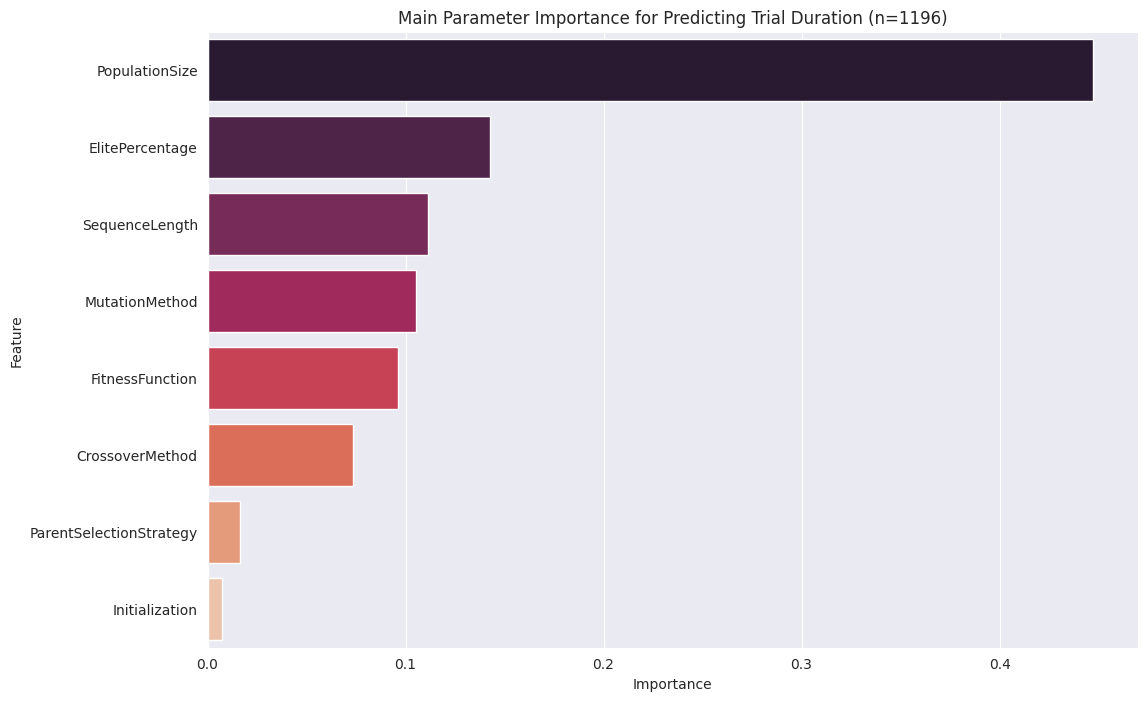

In [7]:


use_trials=['']
analysis_df = df[df['source'].apply(lambda x: any(trial_name in x for trial_name in use_trials))].copy()

duration_feature_cols = [
            'CrossoverMethod', 'ElitePercentage', 'FitnessFunction',
            'Initialization', 'MutationMethod',
            'ParentSelectionStrategy', 'PopulationSize', 'SequenceLength',
        ]

if 'Duration_sec' in analysis_df.columns and not analysis_df.empty:
    # Select features relevant to duration prediction from the specified list
    duration_cols = [col for col in duration_feature_cols if col in analysis_df.columns]
    features_dur = analysis_df[duration_cols]
    target_dur = analysis_df['Duration_sec']
    duration_sample_size = len(analysis_df) # Use the size of the filtered analysis_df

    # Identify categorical columns for encoding
    categorical_cols_dur = [col for col in features_dur.columns if features_dur[col].dtype == 'object']
    features_encoded_dur = pd.get_dummies(features_dur, columns=categorical_cols_dur, dummy_na=False)
    features_encoded_dur.fillna(0, inplace=True) # Fill any remaining NaNs

    # Ensure there are features to train the model
    if not features_encoded_dur.empty:
        model_dur = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        model_dur.fit(features_encoded_dur, target_dur)

        importances_dur = model_dur.feature_importances_
        feature_names_dur = features_encoded_dur.columns

        # Aggregate importances for categorical features if needed
        agg_importance_dur = {}
        for i, name in enumerate(feature_names_dur):
            # Simplified aggregation: if it's an encoded categorical feature, use the base name
            base_name = name.split('_')[0] if '_' in name and name.split('_')[0] in categorical_cols_dur else name
            agg_importance_dur[base_name] = agg_importance_dur.get(base_name, 0) + importances_dur[i]


        agg_importance_df_dur = pd.DataFrame.from_dict(agg_importance_dur, orient='index', columns=['importance']).sort_values(by='importance', ascending=False)
        agg_importance_df_dur['feature'] = agg_importance_df_dur.index

        plt.figure(figsize=(12, 8))
        sns.set_style("darkgrid") # Set style to darkgrid for grey background
        sns.barplot(x='importance', y='feature', data=agg_importance_df_dur, palette='rocket')
        plt.title(f"Main Parameter Importance for Predicting Trial Duration (n={duration_sample_size})")
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.show()
    else:
        print("No features available for duration prediction after filtering.")
else:
    print("Duration_sec column not found or analysis_df is empty after filtering.")

Removed 0 outliers based on 'Value' (IQR method). Analysis includes 290 trials.


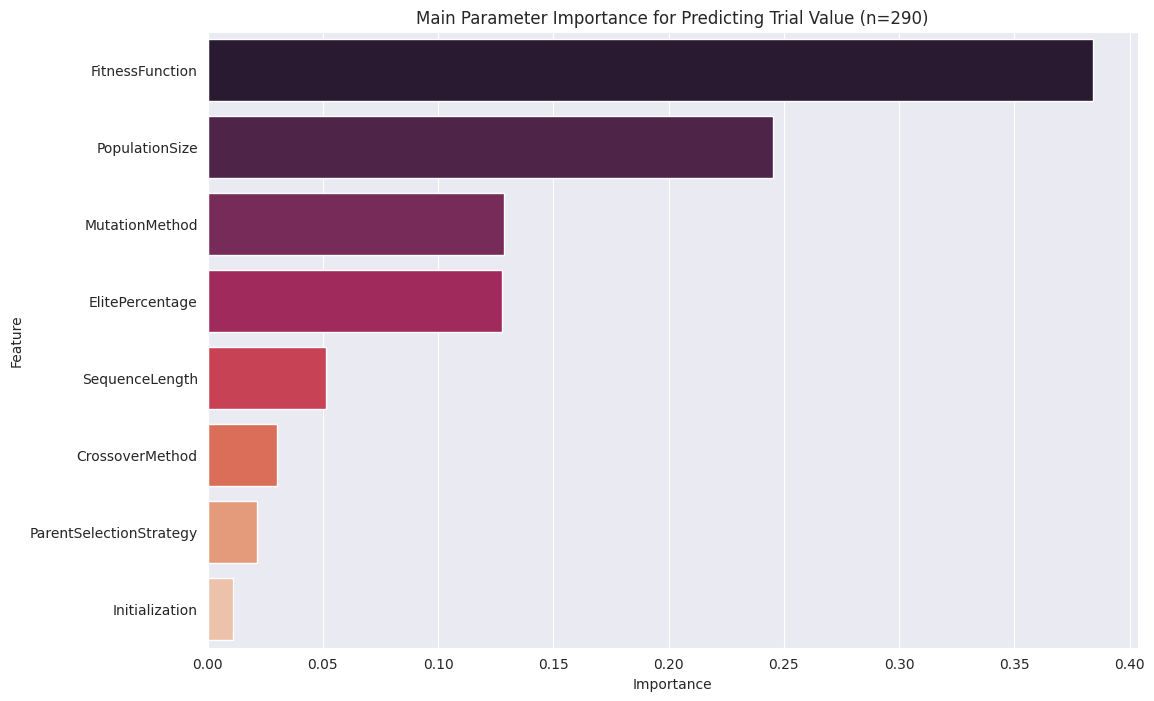

In [8]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

use_trials=['1000TicksAllParameters']#['Aggressive','Balanced','Strategic','50n Study All','14n Study All','30n Study All']
analysis_df = df[df['source'].apply(lambda x: any(trial_name in x for trial_name in use_trials))].copy()

# Define all potential features, including continuous and categorical
all_potential_features = [
            'CrossoverMethod', 'ElitePercentage', 'FitnessFunction',
            'Initialization', 'MutationMethod',
            'ParentSelectionStrategy', 'PopulationSize', 'SequenceLength',
        ]

if 'Value' in analysis_df.columns and not analysis_df.empty:
    # --- Outlier Removal (IQR Method) ---
    Q1 = analysis_df['Value'].quantile(0.25)
    Q3 = analysis_df['Value'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    initial_rows = len(analysis_df)
    #analysis_df = analysis_df[(analysis_df['Value'] >= lower_bound)].copy()
    removed_rows = initial_rows - len(analysis_df)
    print(f"Removed {removed_rows} outliers based on 'Value' (IQR method). Analysis includes {len(analysis_df)} trials.")
    # --- End Outlier Removal ---

    # Select features relevant to value prediction from the specified list
    value_cols = [col for col in all_potential_features if col in analysis_df.columns]
    features_val = analysis_df[value_cols]
    target_val = analysis_df['Value']
    value_sample_size = len(analysis_df) # Use the size of the filtered analysis_df

    # Identify categorical columns for encoding
    categorical_cols_val = [col for col in features_val.columns if features_val[col].dtype == 'object']
    features_encoded_val = pd.get_dummies(features_val, columns=categorical_cols_val, dummy_na=False)
    features_encoded_val.fillna(0, inplace=True) # Fill any remaining NaNs

    # Ensure there are features to train the model
    if not features_encoded_val.empty:
        model_val = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        model_val.fit(features_encoded_val, target_val)

        importances_val = model_val.feature_importances_
        feature_names_val = features_encoded_val.columns

        # Aggregate importances for categorical features if needed
        agg_importance_val = {}
        for i, name in enumerate(feature_names_val):
            # Simplified aggregation: if it's an encoded categorical feature, use the base name
            base_name = name.split('_')[0] if '_' in name and name.split('_')[0] in categorical_cols_val else name
            agg_importance_val[base_name] = agg_importance_val.get(base_name, 0) + importances_val[i] # Changed from importances_dur to importances_val


        agg_importance_df_val = pd.DataFrame.from_dict(agg_importance_val, orient='index', columns=['importance']).sort_values(by='importance', ascending=False)
        agg_importance_df_val['feature'] = agg_importance_df_val.index

        plt.figure(figsize=(12, 8))
        sns.set_style("darkgrid") # Set style to darkgrid for grey background
        sns.barplot(x='importance', y='feature', data=agg_importance_df_val, palette='rocket', hue='feature', legend=False) # Fix for FutureWarning: use hue and legend=False
        plt.title(f"Main Parameter Importance for Predicting Trial Value (n={value_sample_size})")
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.show()
    else:
        print("No features available for value prediction after filtering.")
else:
    print("'Value' column not found or analysis_df is empty after filtering.")

Removed 9 outliers based on 'Value' (IQR method). Analysis includes 281 trials.

--- Analyzing Population Size vs. Sequence Length for the 2 Largest Trials (n=281) ---
Sources: ['db_1000TicksAllParameters']


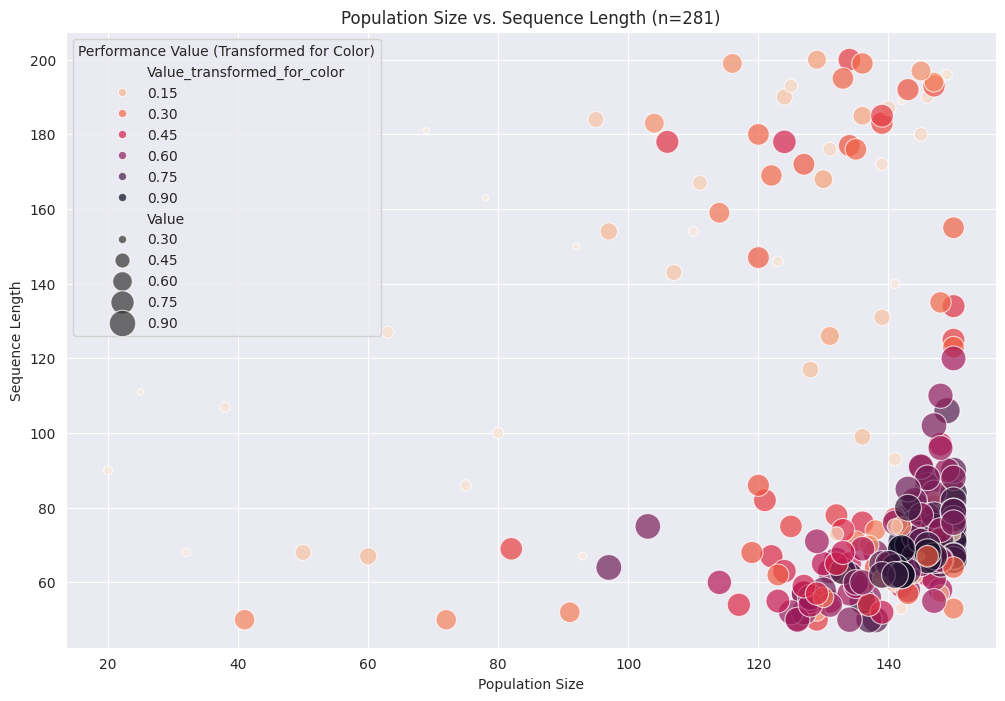

In [9]:
use_trials=['1000TicksAllParameters']

# Filter df to include only the trials specified in use_trials
analysis_df = df[df['source'].apply(lambda x: any(trial_name in x for trial_name in use_trials))].copy()

# c) Scatter plot for population vs sequenceLength for the two largest trials
if not analysis_df.empty:
        # --- Outlier Removal (IQR Method) ---
    Q1 = analysis_df['Value'].quantile(0.25)
    Q3 = analysis_df['Value'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    initial_rows = len(analysis_df)
    analysis_df = analysis_df[(analysis_df['Value'] >= lower_bound)].copy()
    removed_rows = initial_rows - len(analysis_df)
    print(f"Removed {removed_rows} outliers based on 'Value' (IQR method). Analysis includes {len(analysis_df)} trials.")
    # --- End Outlier Removal ---
    # Find the two largest sources (trials) within the analysis data
    filtered_study_summaries = analysis_df['source'].value_counts().index.tolist()
    if filtered_study_summaries:
        scatter_plot_df = analysis_df[analysis_df['source'].isin(filtered_study_summaries)].copy() # Added .copy()

        # Apply a transformation to 'Value' specifically for color mapping
        scatter_plot_df['Value_transformed_for_color'] = scatter_plot_df['Value']**3 # Using square root transformation


        scatter_sample_size = len(scatter_plot_df)

        print(f"\n--- Analyzing Population Size vs. Sequence Length for the 2 Largest Trials (n={scatter_sample_size}) ---")
        print(f"Sources: {filtered_study_summaries}")
        plt.figure(figsize=(12, 8))
        sns.set_style("darkgrid") # Set style to darkgrid for grey background
        sns.scatterplot(
            data=scatter_plot_df,
            x='PopulationSize',
            y='SequenceLength',
            size='Value', # Size still based on original Value
            hue='Value_transformed_for_color', # Hue based on transformed Value
            sizes=(20, 400),
            palette='rocket_r', # Use rocket_r palette
            alpha=0.7
        )
        plt.title(f'Population Size vs. Sequence Length (n={scatter_sample_size})')
        plt.xlabel('Population Size')
        plt.ylabel('Sequence Length')
        # Update legend title to reflect the transformation if necessary, or keep as Value for simplicity
        plt.legend(title='Performance Value (Transformed for Color)')
        plt.show()

In [10]:
def plot_continuous_feature_vs_value(df, continuous_feature, use_trials):
    """
    Generates a scatter plot of a continuous feature vs. the 'Value' with a fitted regression line,
    and prints descriptive statistics and correlation.

    Args:
        df (pd.DataFrame): The input DataFrame containing the trial data.
        continuous_feature (str): The name of the continuous feature column to plot on the x-axis.
        use_trials (list): A list of trial names to include in the analysis.
    """
    analysis_df_continuous = df[df['source'].apply(lambda x: any(trial_name in x for trial_name in use_trials))].copy()

        # --- Outlier Removal (IQR Method) ---
    Q1 = analysis_df_continuous['Value'].quantile(0.25)
    Q3 = analysis_df_continuous['Value'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    initial_rows = len(analysis_df_continuous)
    #analysis_df_continuous = analysis_df_continuous[(analysis_df_continuous['Value'] >= lower_bound)].copy()
    removed_rows = initial_rows - len(analysis_df_continuous)
    print(f"Removed {removed_rows} outliers based on 'Value' (IQR method). Analysis includes {len(analysis_df)} trials.")
    # --- End Outlier Removal ---

    # Filter trials where continuous_feature and 'Value' are not null
    analysis_df_continuous = analysis_df_continuous.dropna(subset=[continuous_feature, 'Value']).copy()

    if not analysis_df_continuous.empty:
        plt.figure(figsize=(12, 7))
        sns.set_style("darkgrid") # Set style to darkgrid for grey background
        sns.scatterplot(data=analysis_df_continuous, x=continuous_feature, y='Value',s=200) # Use regplot for scatter and fitted line, with order=2 for polynomial
        plt.title(f'Performance vs. {continuous_feature} (n={analysis_df_continuous.shape[0]})', fontsize=16)
        plt.xlabel(continuous_feature, fontsize=12)
        plt.ylabel('Performance', fontsize=12)
        plt.tight_layout()
        plt.show()

        # Optionally, display some descriptive statistics for the continuous feature
        print(f"\n--- Descriptive Statistics for {continuous_feature} ---")
        print(analysis_df_continuous[continuous_feature].describe())
        print(f"\n--- Correlation between {continuous_feature} and Value ---")
        print(analysis_df_continuous[[continuous_feature, 'Value']].corr().iloc[0, 1])

    else:
        print(f"\nNot enough data with non-null '{continuous_feature}' and 'Value' in the filtered data to plot.")

Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


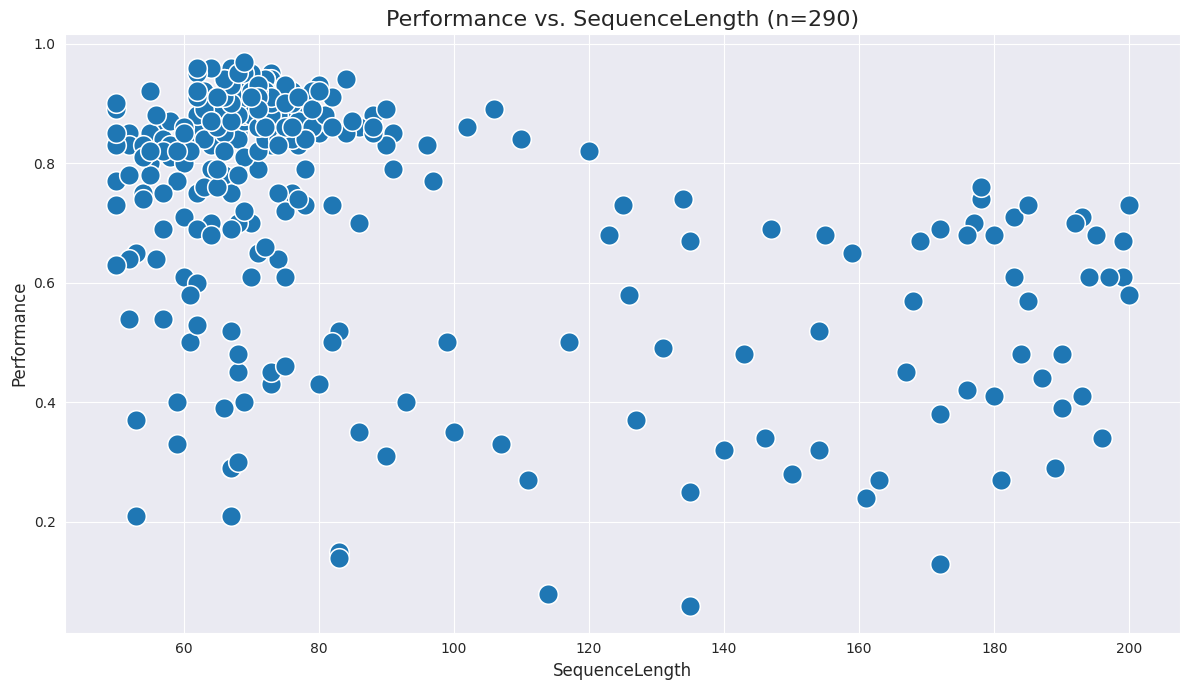


--- Descriptive Statistics for SequenceLength ---
count    290.000000
mean      88.779310
std       41.332389
min       50.000000
25%       64.250000
50%       72.000000
75%       88.000000
max      200.000000
Name: SequenceLength, dtype: float64

--- Correlation between SequenceLength and Value ---
-0.446524949474525
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


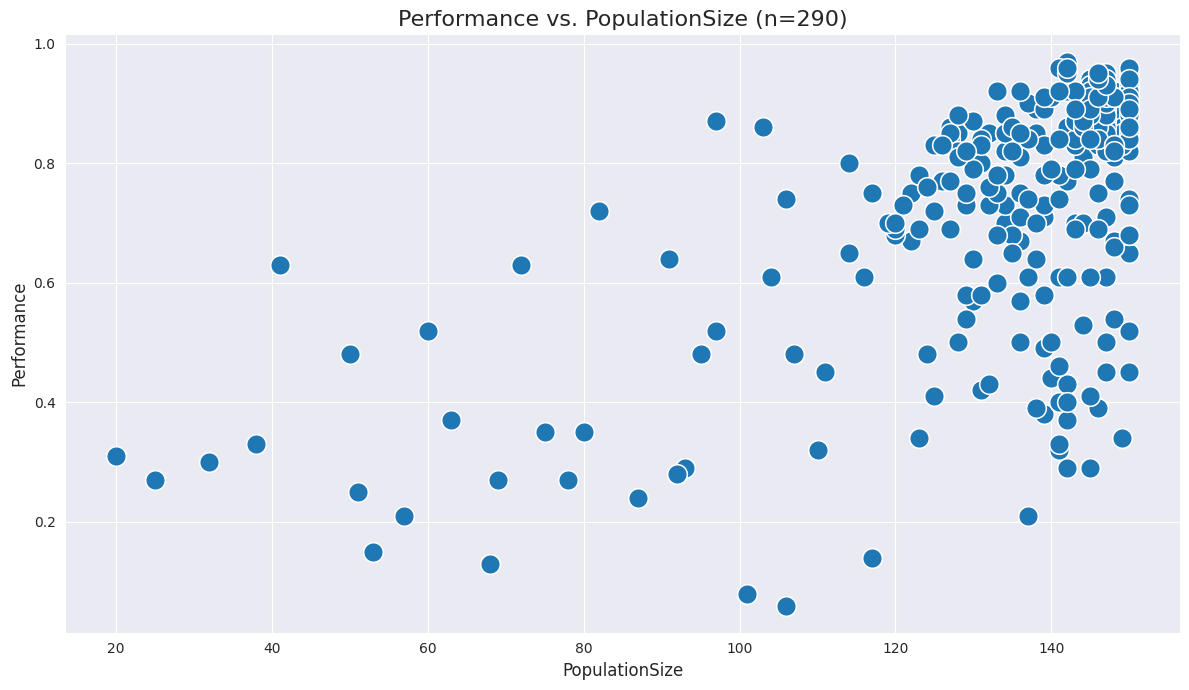


--- Descriptive Statistics for PopulationSize ---
count    290.000000
mean     133.068966
std       23.739111
min       20.000000
25%      130.000000
50%      142.000000
75%      147.000000
max      150.000000
Name: PopulationSize, dtype: float64

--- Correlation between PopulationSize and Value ---
0.5848395431712617


In [11]:
plot_continuous_feature_vs_value(df, 'SequenceLength', ["1000TicksAllParameters"]);
plot_continuous_feature_vs_value(df, 'PopulationSize', ["1000TicksAllParameters"]);

Now you can use the `plot_continuous_feature_vs_value` method like this:

Generating plots for all continuous parameters:

--- Plotting Aggressive_PlanetWeight vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


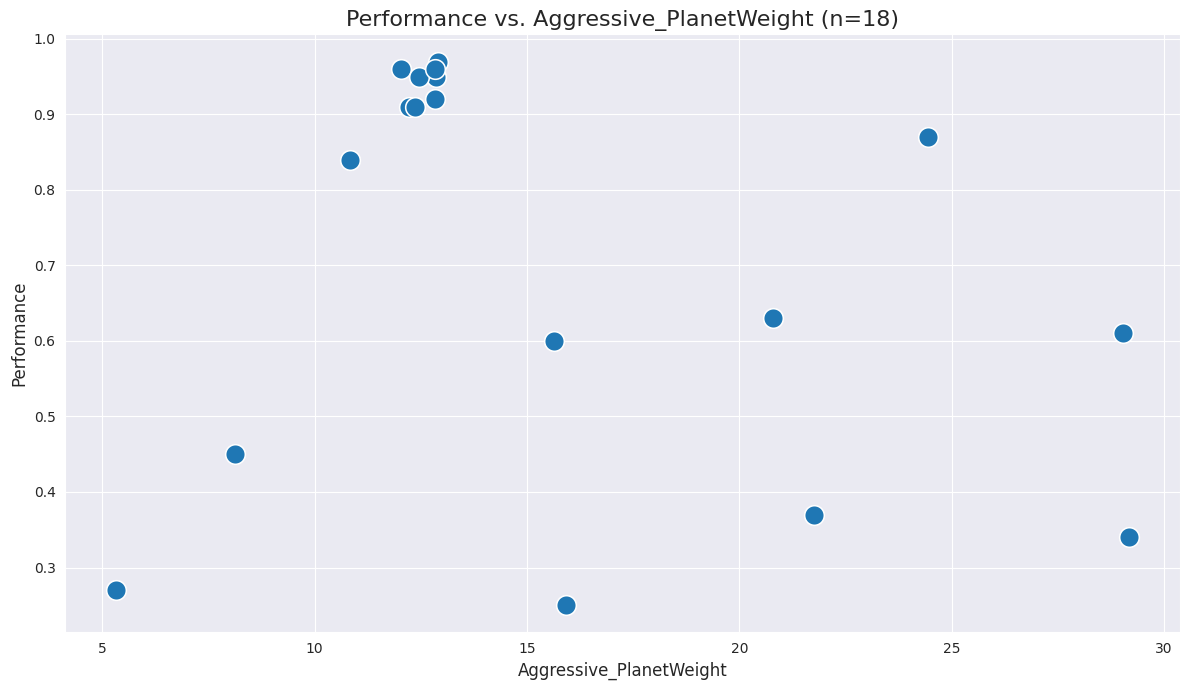


--- Descriptive Statistics for Aggressive_PlanetWeight ---
count    18.000000
mean     15.642876
std       6.715924
min       5.323973
25%      12.266596
50%      12.841102
75%      19.576399
max      29.179534
Name: Aggressive_PlanetWeight, dtype: float64

--- Correlation between Aggressive_PlanetWeight and Value ---
-0.24003039129664747

--- Plotting Aggressive_ShipWeight vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


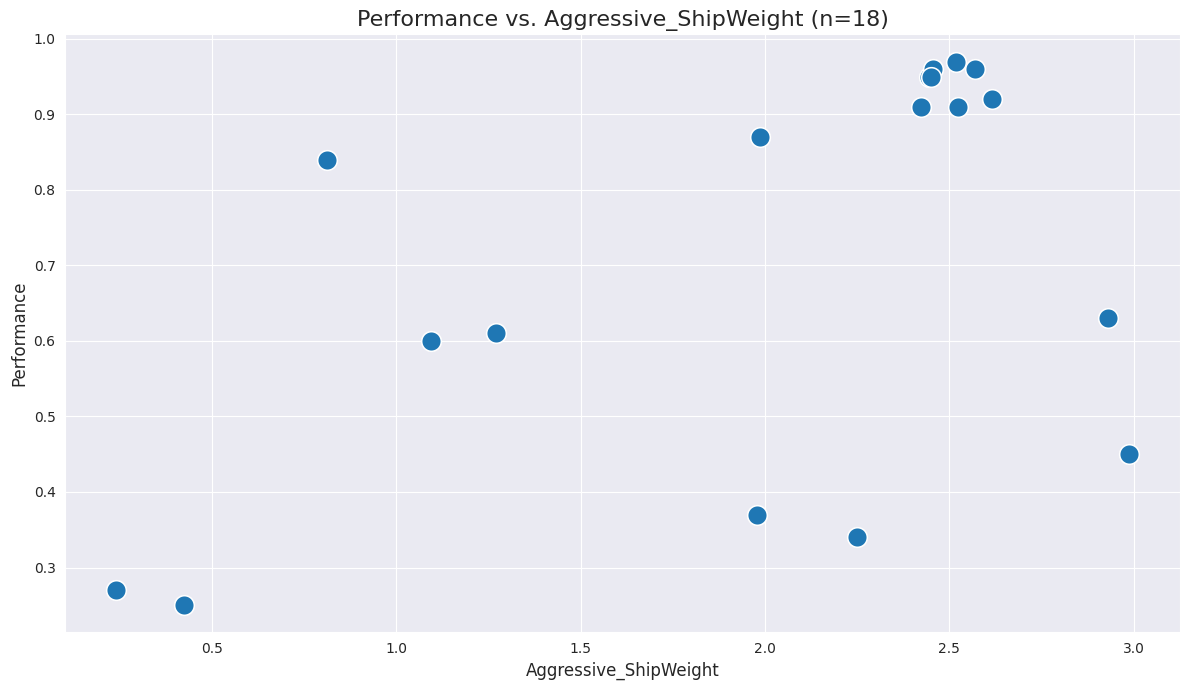


--- Descriptive Statistics for Aggressive_ShipWeight ---
count    18.000000
mean      1.998315
std       0.850279
min       0.238831
25%       1.446311
50%       2.434363
75%       2.521620
max       2.988304
Name: Aggressive_ShipWeight, dtype: float64

--- Correlation between Aggressive_ShipWeight and Value ---
0.5210214978556805

--- Plotting Aggressive_TimePenalty/Tick vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


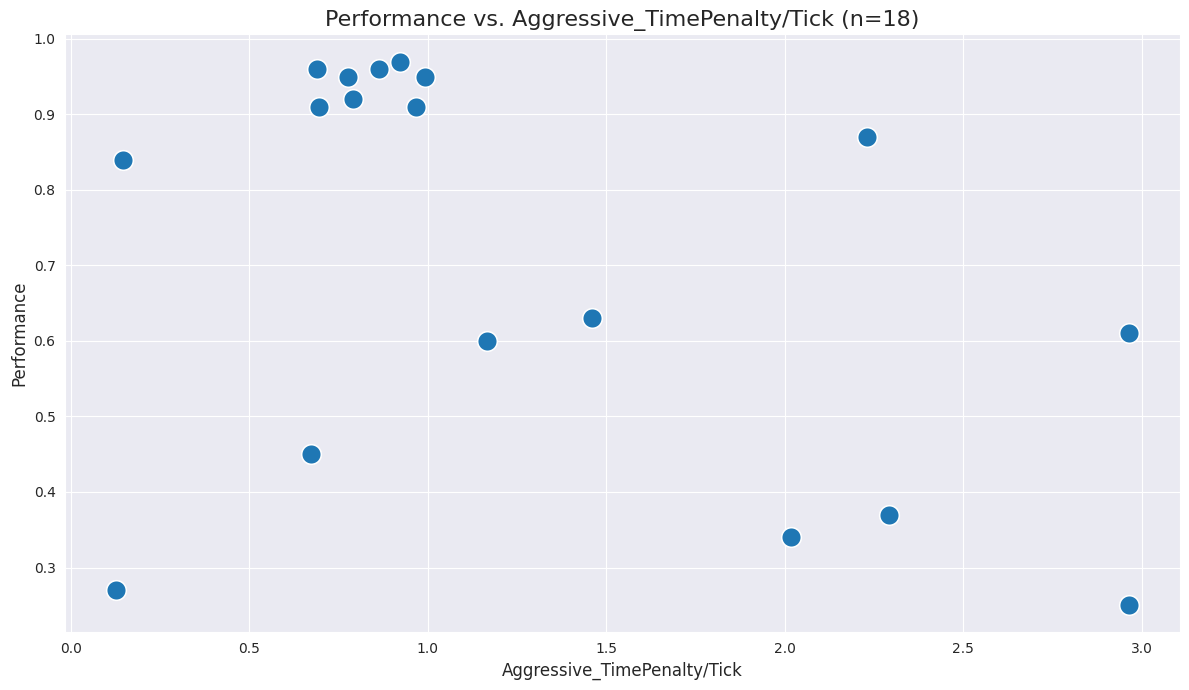


--- Descriptive Statistics for Aggressive_TimePenalty/Tick ---
count    18.000000
mean      1.263300
std       0.868882
min       0.126888
25%       0.715348
50%       0.945140
75%       1.877436
max       2.964931
Name: Aggressive_TimePenalty/Tick, dtype: float64

--- Correlation between Aggressive_TimePenalty/Tick and Value ---
-0.43052386645282126

--- Plotting ElitePercentage vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


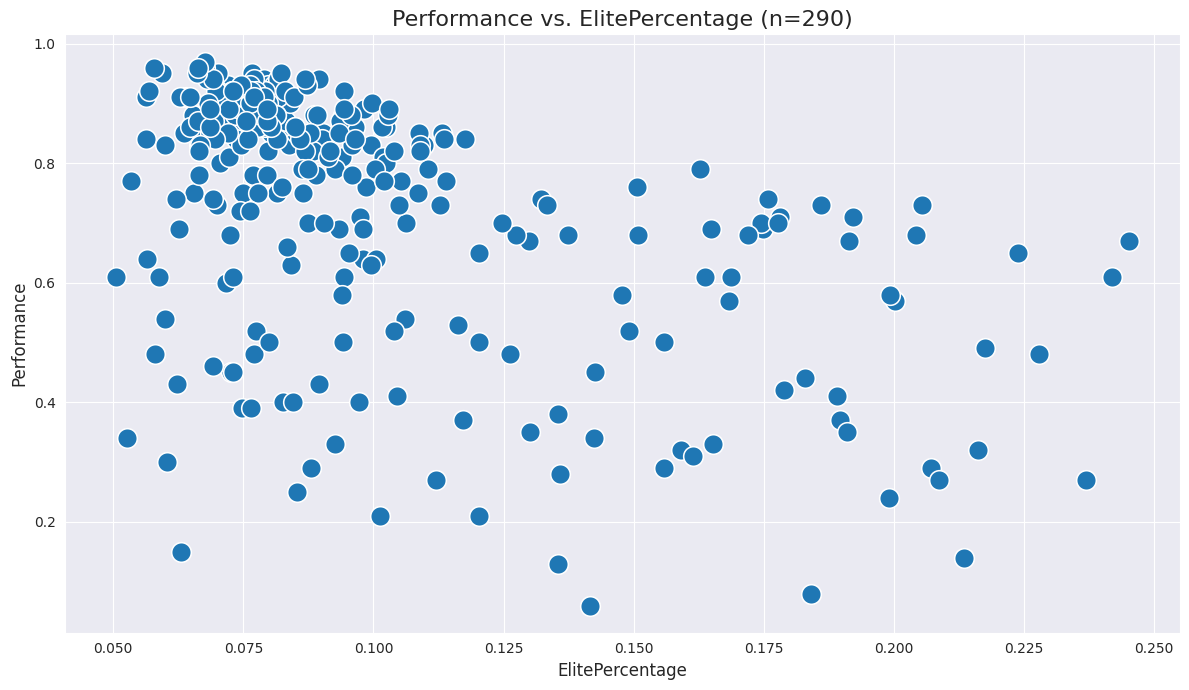


--- Descriptive Statistics for ElitePercentage ---
count    290.000000
mean       0.100731
std        0.041583
min        0.050508
25%        0.073908
50%        0.085015
75%        0.108845
max        0.245267
Name: ElitePercentage, dtype: float64

--- Correlation between ElitePercentage and Value ---
-0.5085374044659331

--- Plotting IslaPercent vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


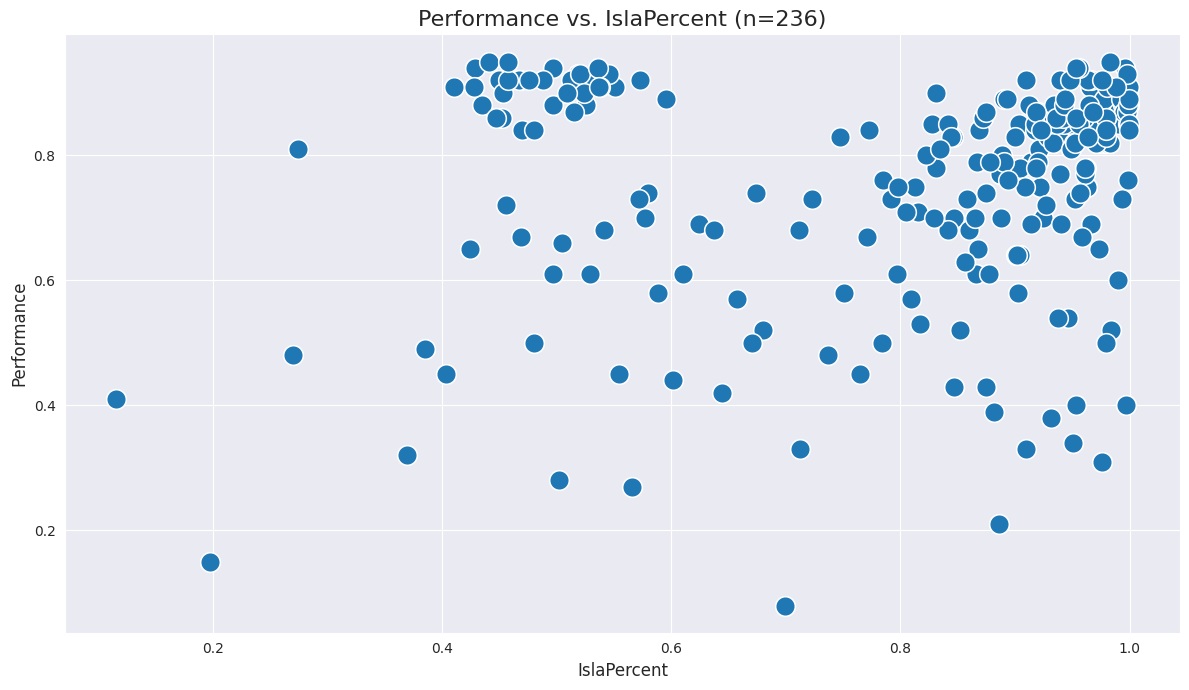


--- Descriptive Statistics for IslaPercent ---
count    236.000000
mean       0.797878
std        0.203565
min        0.115502
25%        0.620783
50%        0.888663
75%        0.956028
max        0.999683
Name: IslaPercent, dtype: float64

--- Correlation between IslaPercent and Value ---
0.14560119404014463

--- Plotting MutationPercent vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.

Not enough data with non-null 'MutationPercent' and 'Value' in the filtered data to plot.

--- Plotting ParentSelectionTournamentSize vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


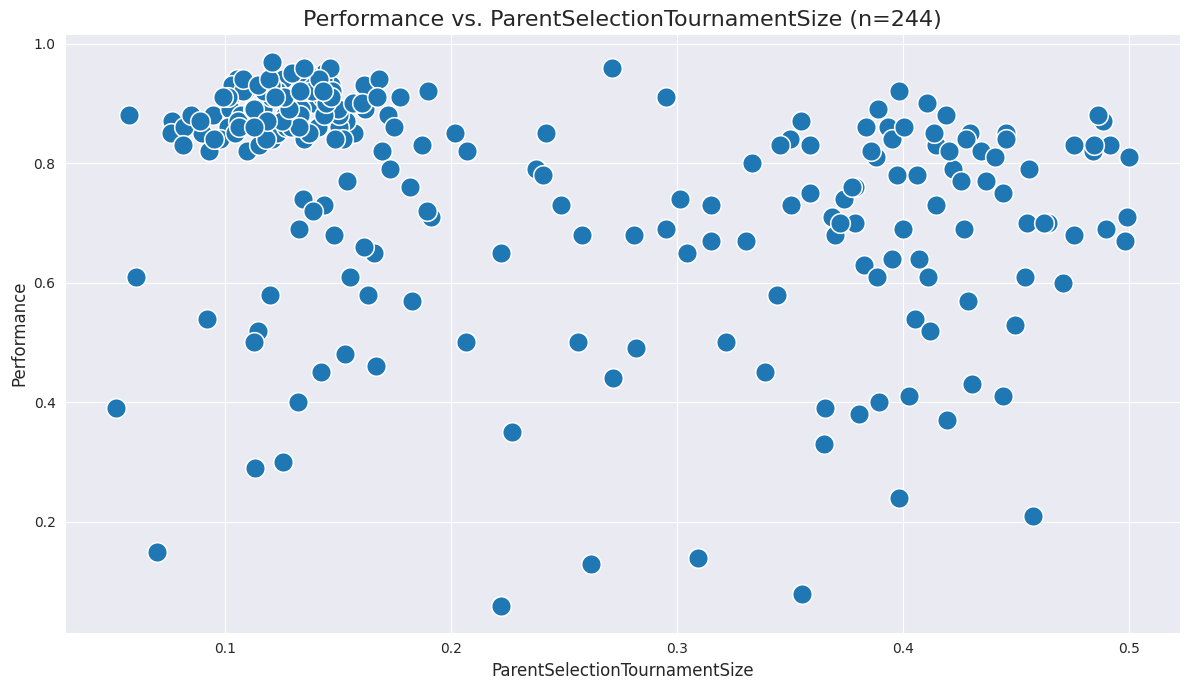


--- Descriptive Statistics for ParentSelectionTournamentSize ---
count    244.000000
mean       0.239306
std        0.134871
min        0.051592
25%        0.128922
50%        0.164510
75%        0.381001
max        0.499988
Name: ParentSelectionTournamentSize, dtype: float64

--- Correlation between ParentSelectionTournamentSize and Value ---
-0.3081310367245901

--- Plotting PopulationSize vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


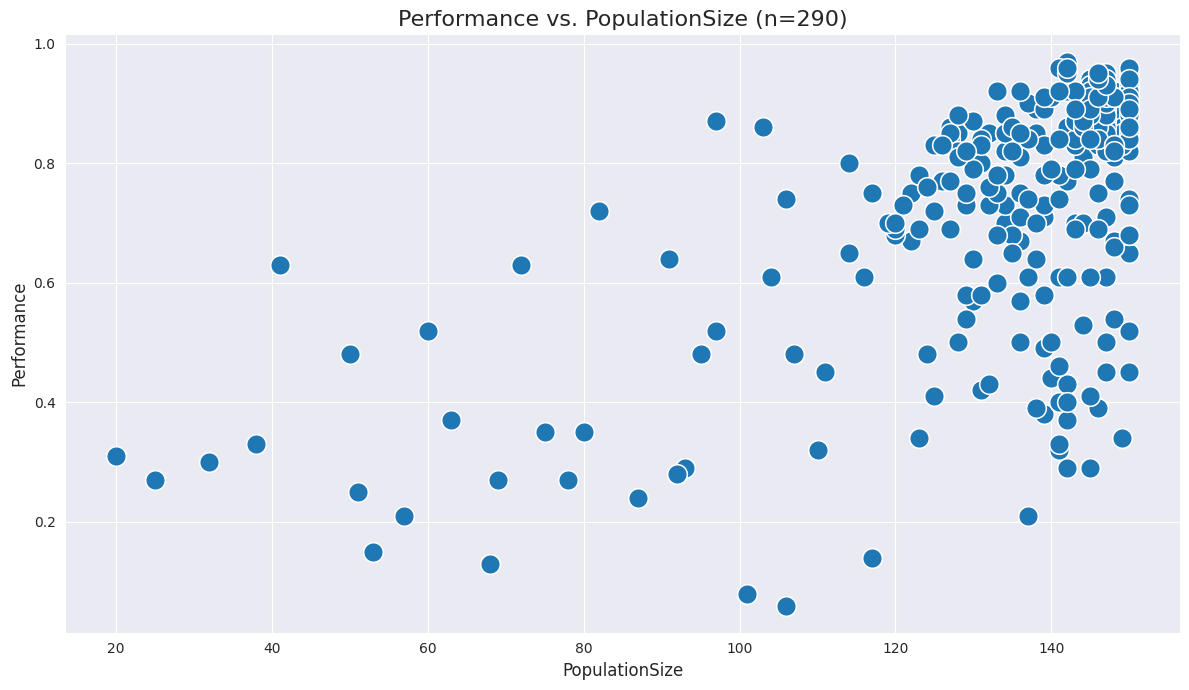


--- Descriptive Statistics for PopulationSize ---
count    290.000000
mean     133.068966
std       23.739111
min       20.000000
25%      130.000000
50%      142.000000
75%      147.000000
max      150.000000
Name: PopulationSize, dtype: float64

--- Correlation between PopulationSize and Value ---
0.5848395431712617

--- Plotting SequenceLength vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


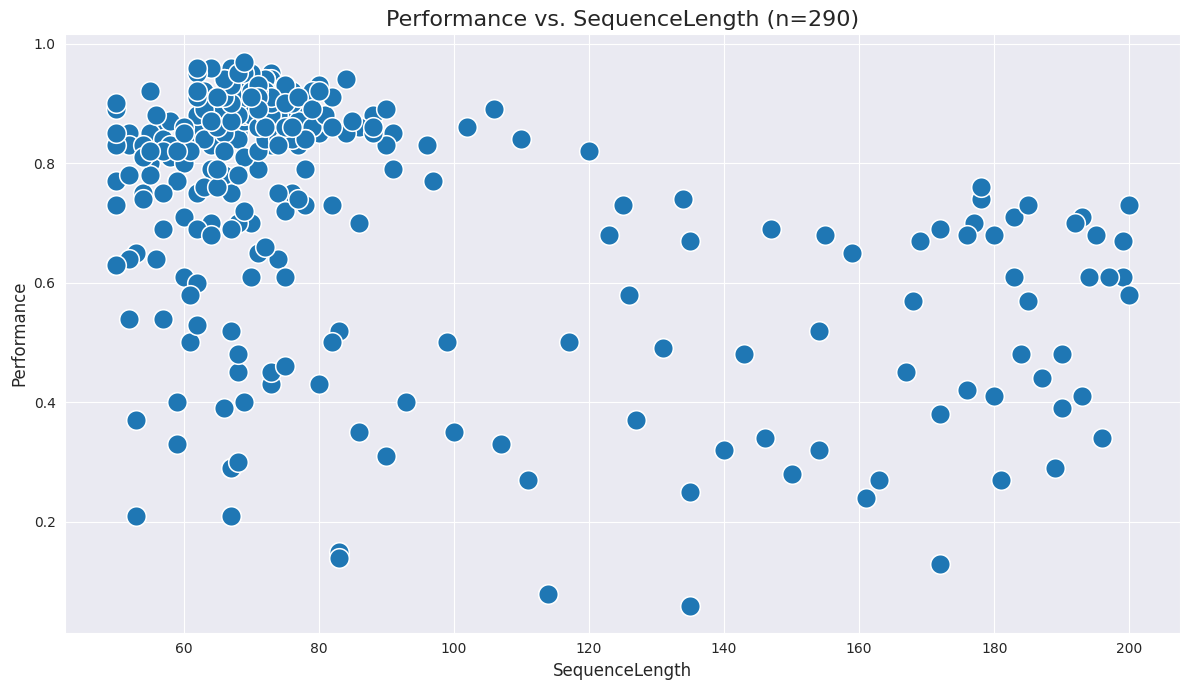


--- Descriptive Statistics for SequenceLength ---
count    290.000000
mean      88.779310
std       41.332389
min       50.000000
25%       64.250000
50%       72.000000
75%       88.000000
max      200.000000
Name: SequenceLength, dtype: float64

--- Correlation between SequenceLength and Value ---
-0.446524949474525

--- Plotting Strategic_GrowthWeight vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.

Not enough data with non-null 'Strategic_GrowthWeight' and 'Value' in the filtered data to plot.

--- Plotting Strategic_PlanetWeight vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.

Not enough data with non-null 'Strategic_PlanetWeight' and 'Value' in the filtered data to plot.

--- Plotting Strategic_ShipWeight vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.

Not enough data with non-null 'Strategic_ShipWeight' and 'Value' in the filtered data to pl

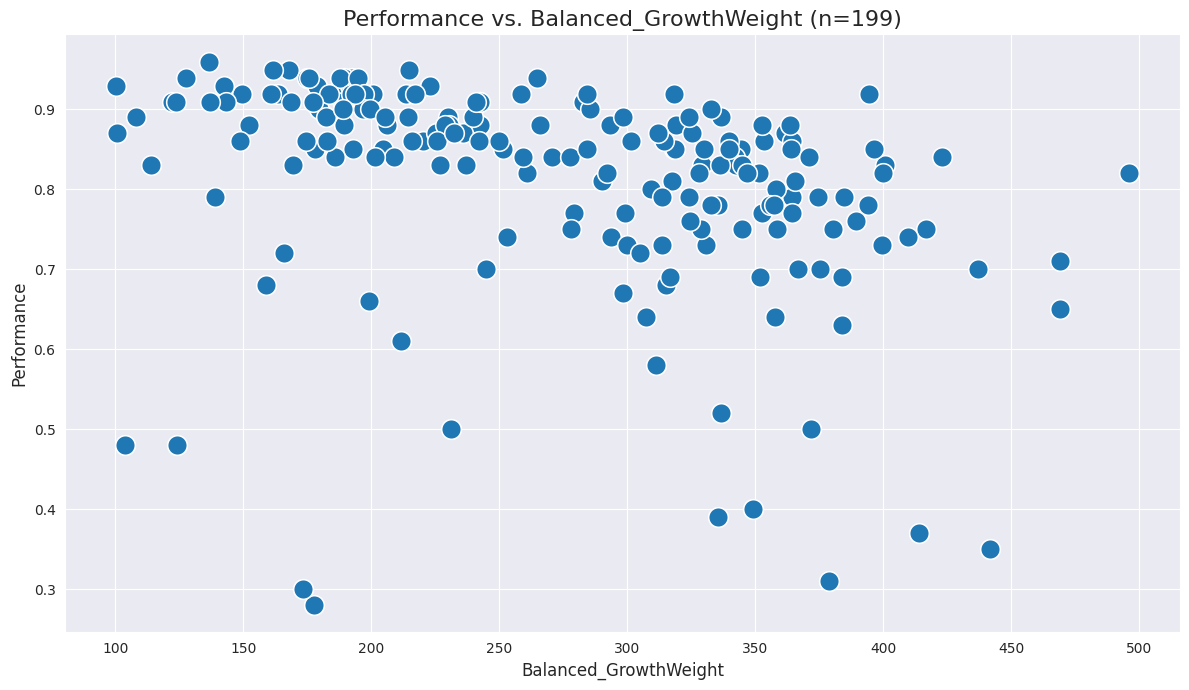


--- Descriptive Statistics for Balanced_GrowthWeight ---
count    199.000000
mean     272.257414
std       87.846165
min      100.259643
25%      194.309521
50%      279.270756
75%      342.991032
max      496.196653
Name: Balanced_GrowthWeight, dtype: float64

--- Correlation between Balanced_GrowthWeight and Value ---
-0.3393508179957968

--- Plotting Balanced_ShipWeight vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


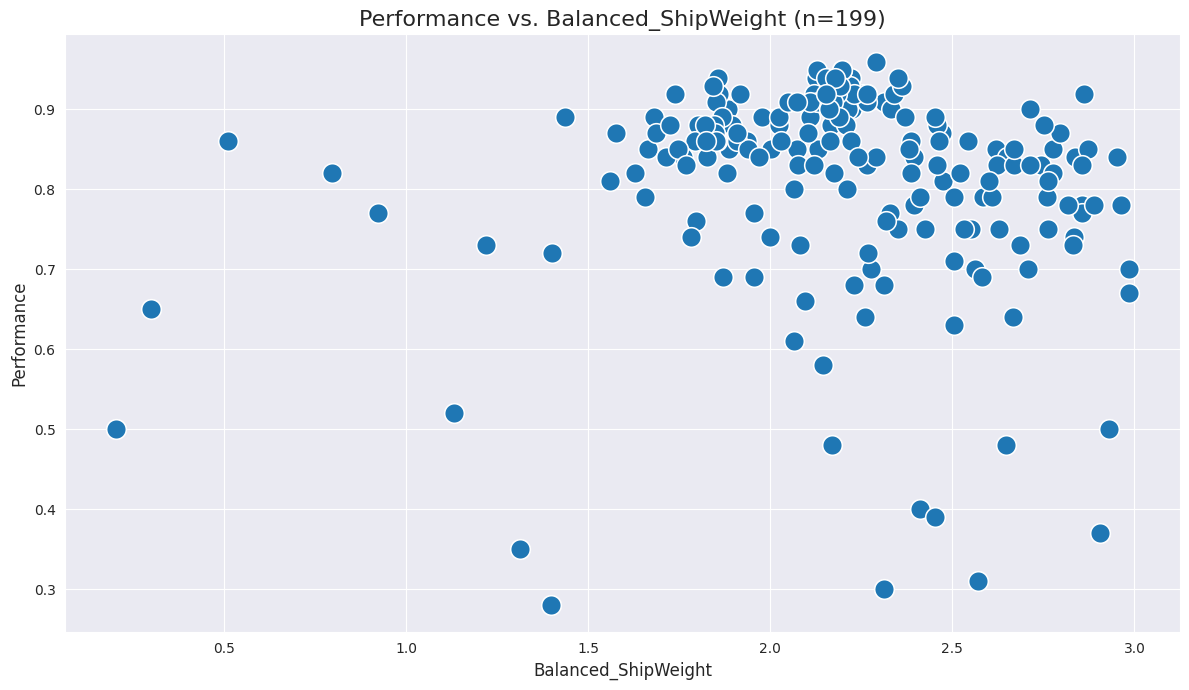


--- Descriptive Statistics for Balanced_ShipWeight ---
count    199.000000
mean       2.185810
std        0.459849
min        0.203775
25%        1.912314
50%        2.198760
75%        2.472570
max        2.985889
Name: Balanced_ShipWeight, dtype: float64

--- Correlation between Balanced_ShipWeight and Value ---
-0.01668866746278318

--- Plotting Hybrid_AggressiveWeight vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


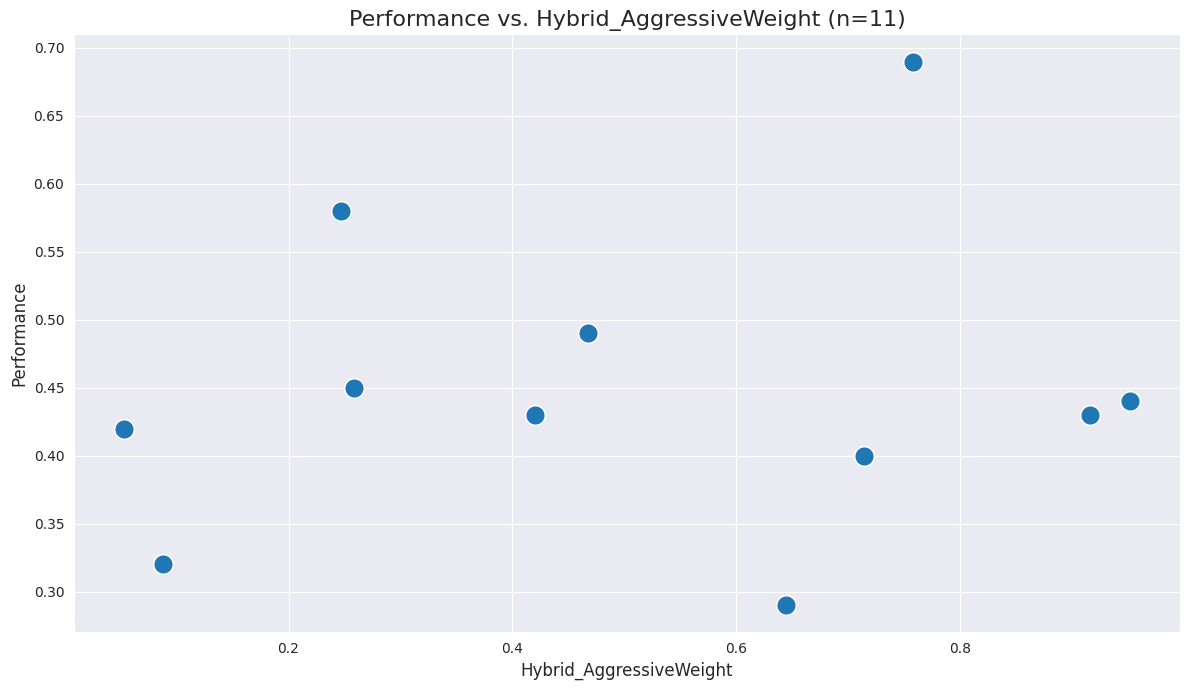


--- Descriptive Statistics for Hybrid_AggressiveWeight ---
count    11.000000
mean      0.501620
std       0.317618
min       0.053312
25%       0.252347
50%       0.467539
75%       0.735929
max       0.951396
Name: Hybrid_AggressiveWeight, dtype: float64

--- Correlation between Hybrid_AggressiveWeight and Value ---
0.14056861343376523

--- Plotting CrossoverNPoints vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


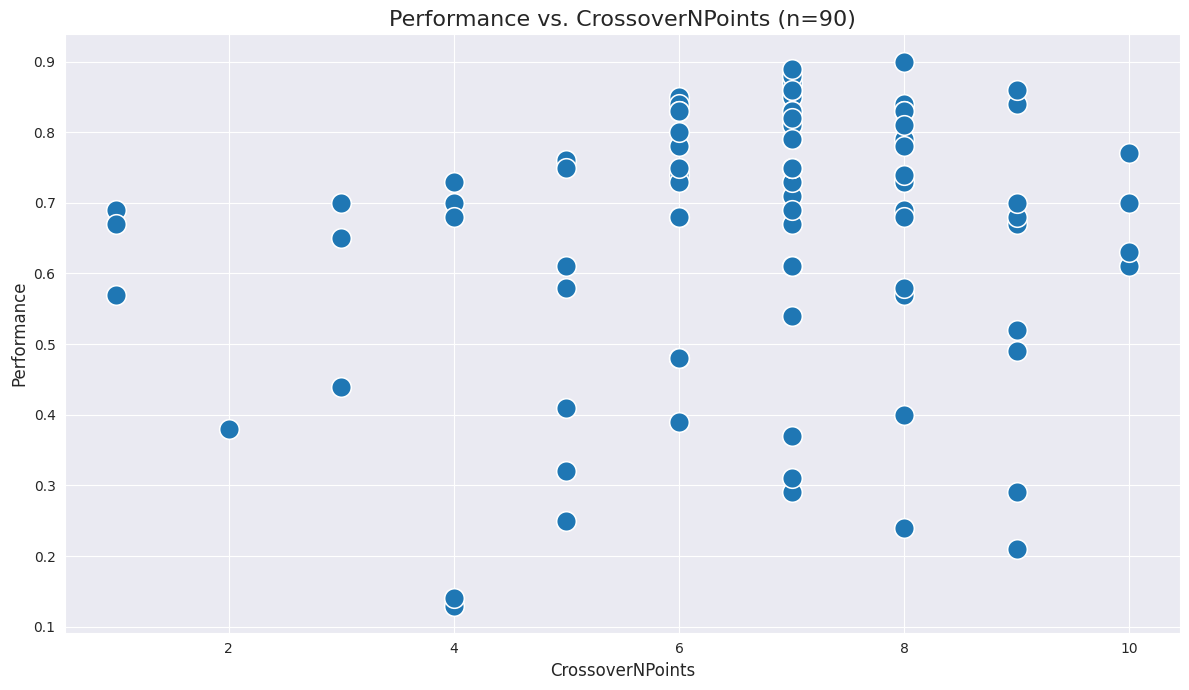


--- Descriptive Statistics for CrossoverNPoints ---
count    90.000000
mean      6.644444
std       1.973482
min       1.000000
25%       6.000000
50%       7.000000
75%       8.000000
max      10.000000
Name: CrossoverNPoints, dtype: float64

--- Correlation between CrossoverNPoints and Value ---
0.17966813554954866

--- Plotting params_fitness.strategic_growth_weight vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


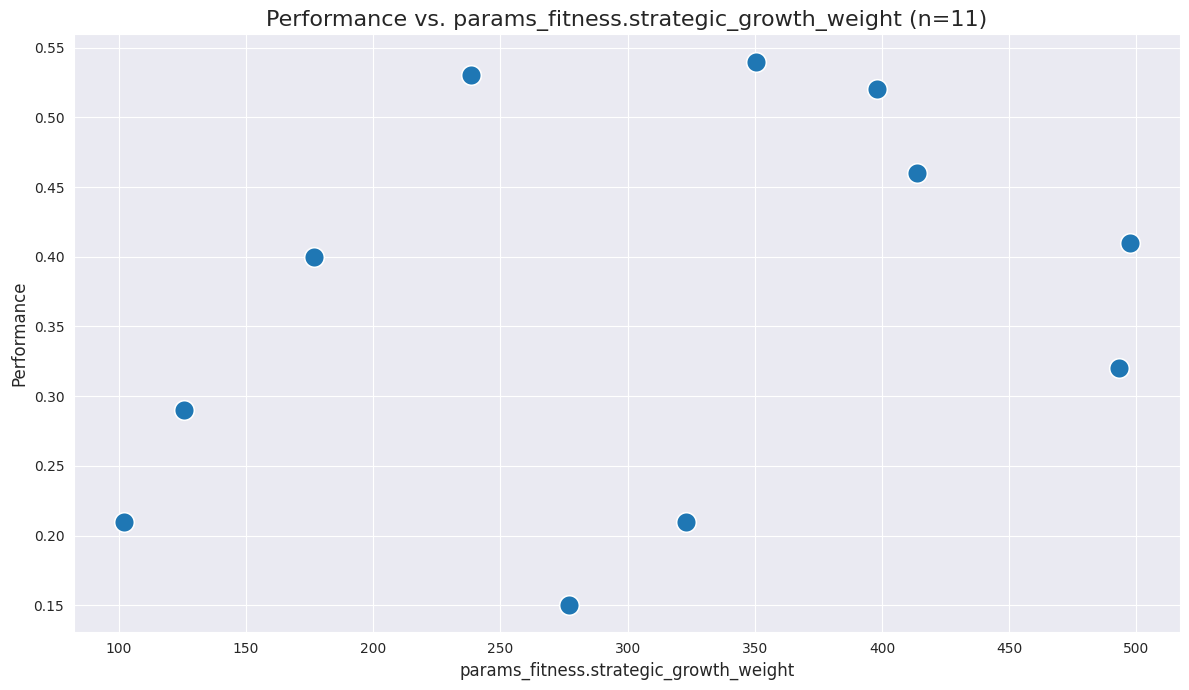


--- Descriptive Statistics for params_fitness.strategic_growth_weight ---
count     11.000000
mean     308.717797
std      137.884807
min      102.158925
25%      207.619476
50%      323.083186
75%      405.971896
max      497.346272
Name: params_fitness.strategic_growth_weight, dtype: float64

--- Correlation between params_fitness.strategic_growth_weight and Value ---
0.33919550218898226

--- Plotting params_fitness.strategic_planet_weight vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


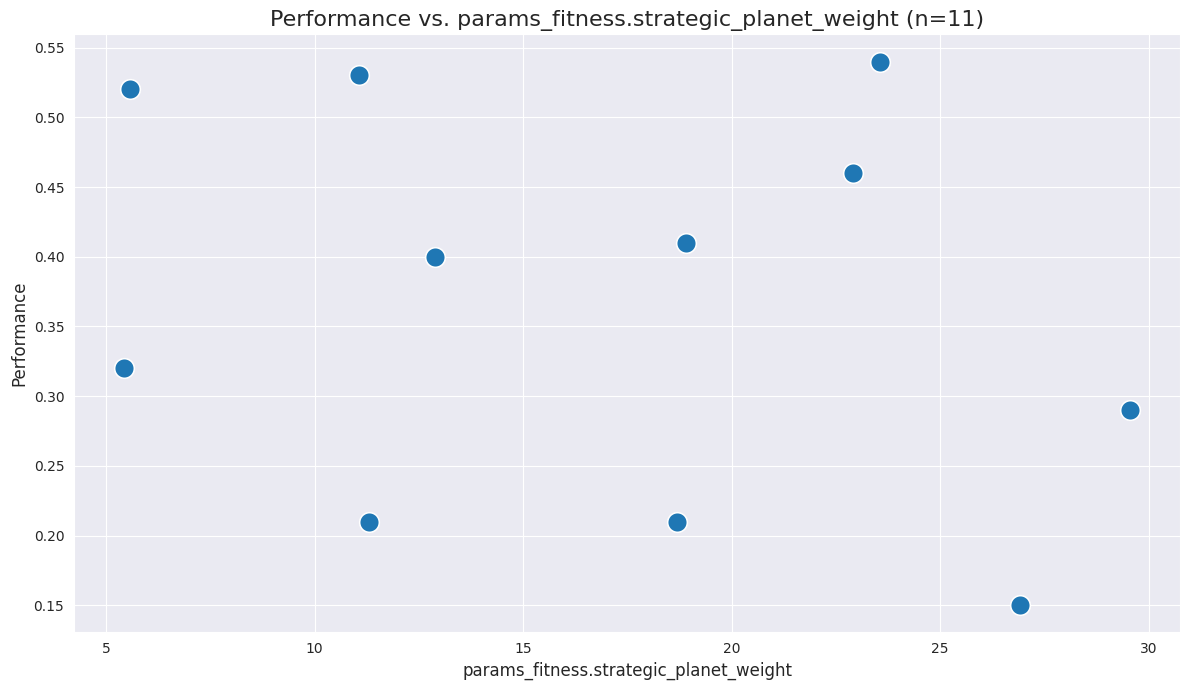


--- Descriptive Statistics for params_fitness.strategic_planet_weight ---
count    11.000000
mean     16.985629
std       8.301576
min       5.437167
25%      11.183547
50%      18.696940
75%      23.244655
max      29.546982
Name: params_fitness.strategic_planet_weight, dtype: float64

--- Correlation between params_fitness.strategic_planet_weight and Value ---
-0.2605818639329569

--- Plotting params_fitness.strategic_ship_weight vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


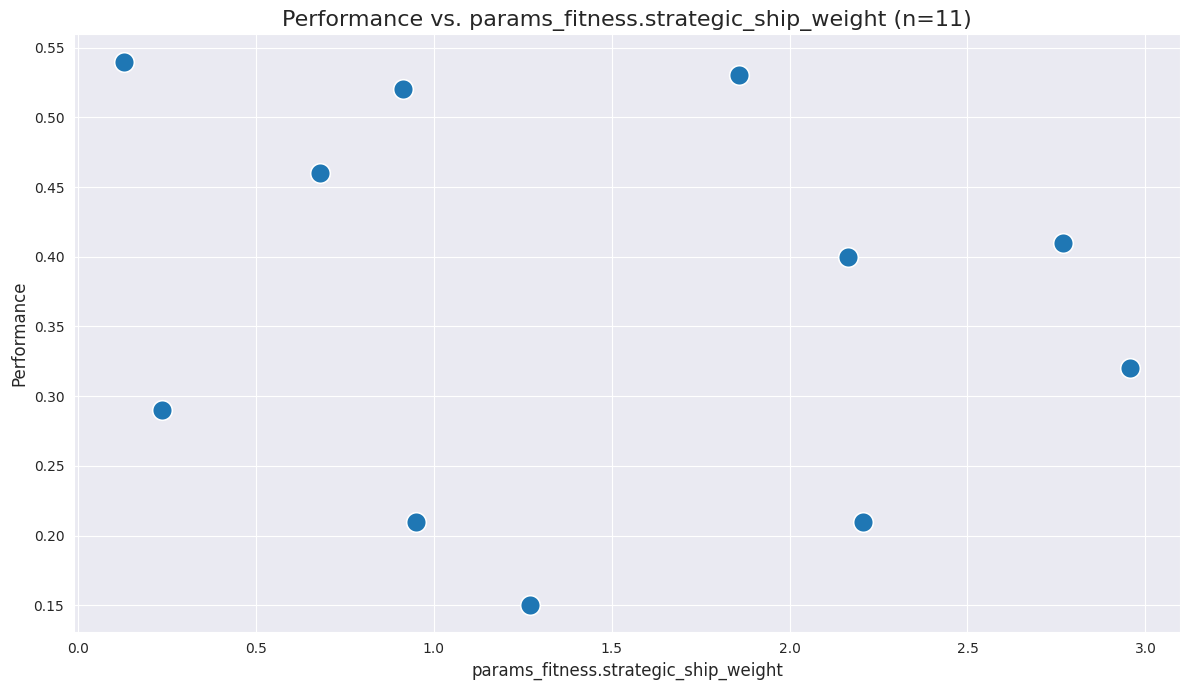


--- Descriptive Statistics for params_fitness.strategic_ship_weight ---
count    11.000000
mean      1.466840
std       0.981026
min       0.130974
25%       0.796682
50%       1.270265
75%       2.185966
max       2.955911
Name: params_fitness.strategic_ship_weight, dtype: float64

--- Correlation between params_fitness.strategic_ship_weight and Value ---
-0.15562773637769148

--- Plotting params_fitness.strategic_time_weight vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


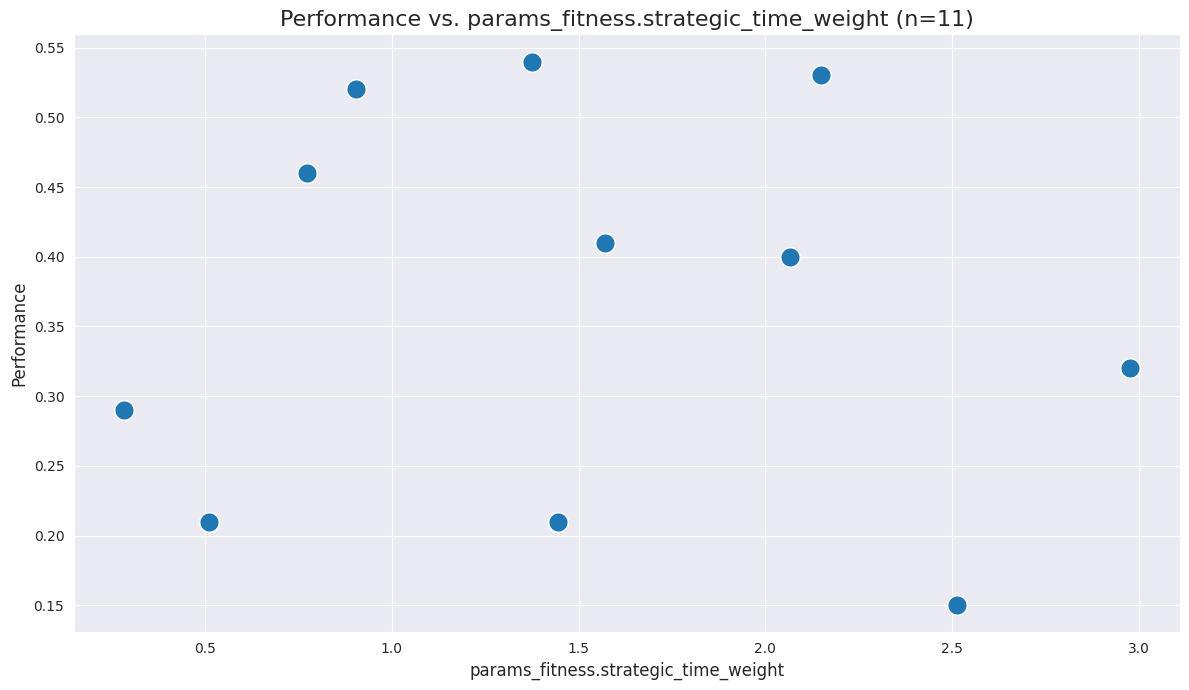


--- Descriptive Statistics for params_fitness.strategic_time_weight ---
count    11.000000
mean      1.506524
std       0.854933
min       0.283924
25%       0.838463
50%       1.446028
75%       2.107620
max       2.975720
Name: params_fitness.strategic_time_weight, dtype: float64

--- Correlation between params_fitness.strategic_time_weight and Value ---
-0.07060544443690597

--- Plotting MutationNBits vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


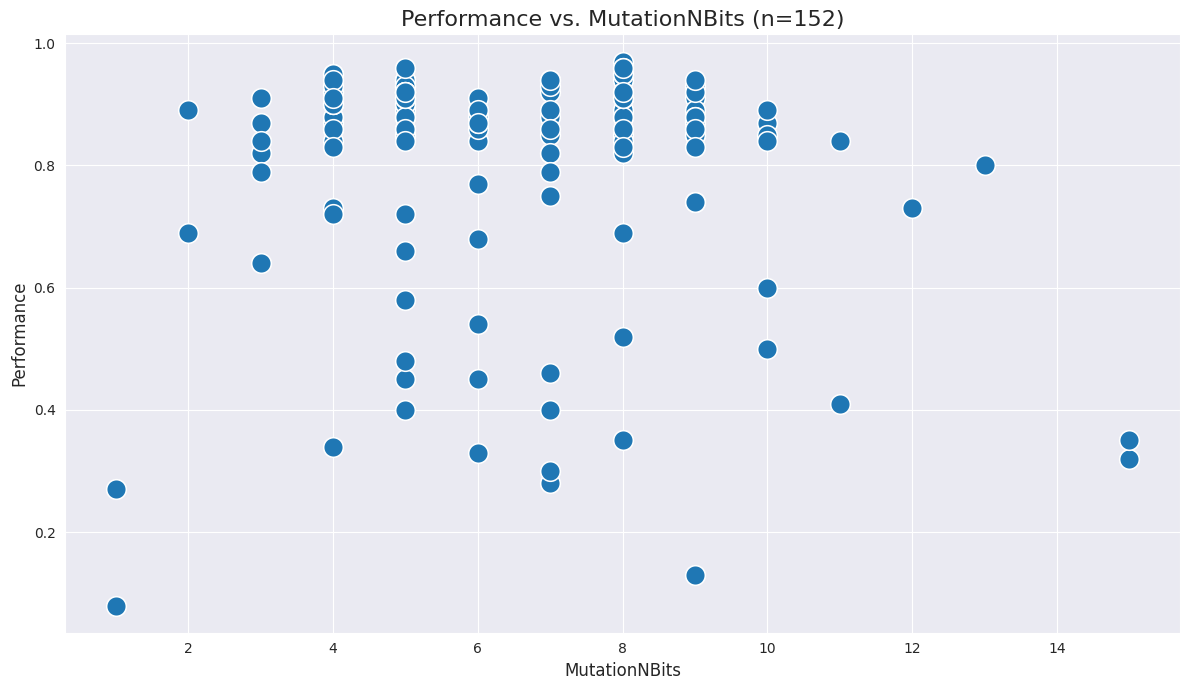


--- Descriptive Statistics for MutationNBits ---
count    152.000000
mean       6.414474
std        2.428975
min        1.000000
25%        5.000000
50%        6.000000
75%        8.000000
max       15.000000
Name: MutationNBits, dtype: float64

--- Correlation between MutationNBits and Value ---
-0.10302227585049115

--- Plotting MutationUniformProbability vs. Value ---
Removed 0 outliers based on 'Value' (IQR method). Analysis includes 281 trials.


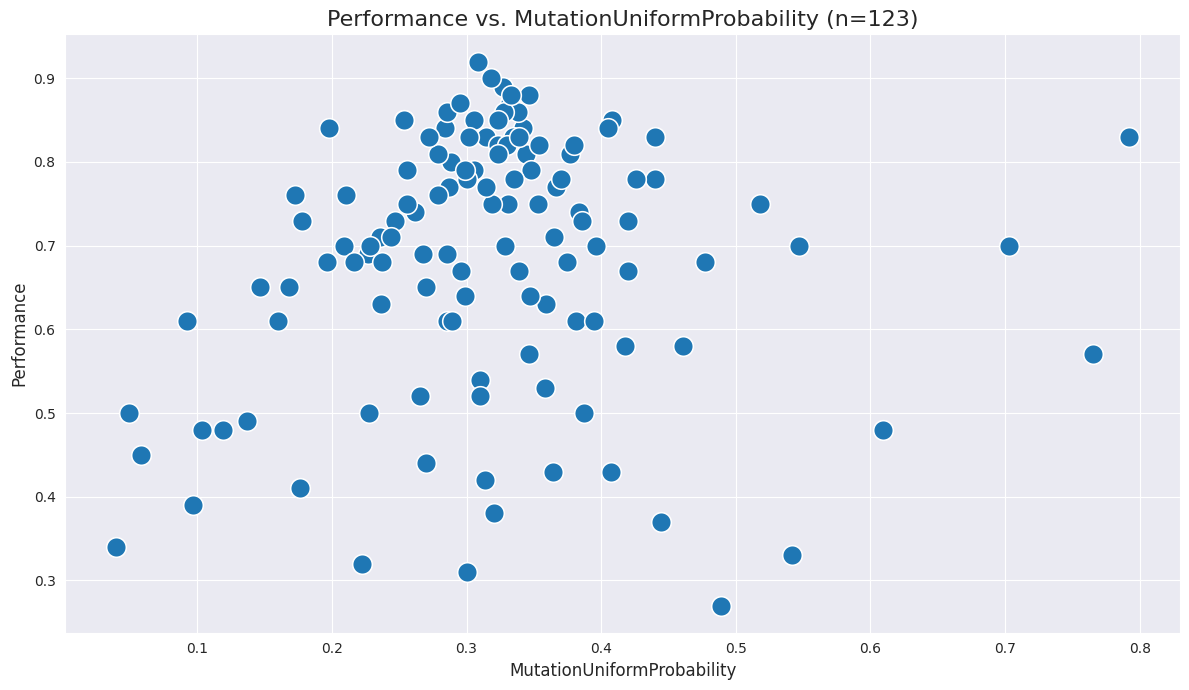


--- Descriptive Statistics for MutationUniformProbability ---
count    123.000000
mean       0.317672
std        0.121334
min        0.039608
25%        0.255804
50%        0.314572
75%        0.365468
max        0.792230
Name: MutationUniformProbability, dtype: float64

--- Correlation between MutationUniformProbability and Value ---
0.11929862608998287


In [12]:
# The list of core metric parameters was defined in cell knk1VKOXkhAe
# core_metric_params = ['PopulationSize', 'SequenceLength']

# Identify all continuous features in the dataframe
all_continuous_params = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col]) and col not in ['Number', 'Value', 'Duration_sec']]

use_trials=['1000TicksAllParameters']

if all_continuous_params:
    print("Generating plots for all continuous parameters:")
    for param in all_continuous_params:
        print(f"\n--- Plotting {param} vs. Value ---")
        plot_continuous_feature_vs_value(df, param, use_trials)
else:
    print("No continuous parameters found in the dataframe.")

In [13]:
def plot_categorical_feature_vs_value(df, categorical_feature, use_trials):
    """
    Generates a box plot of a categorical feature vs. the 'Value' and prints descriptive statistics.

    Args:
        df (pd.DataFrame): The input DataFrame containing the trial data.
        categorical_feature (str): The name of the categorical feature column to plot on the x-axis.
        use_trials (list): A list of trial names to include in the analysis.
    """
    analysis_df_categorical = df[df['source'].apply(lambda x: any(trial_name in x for trial_name in use_trials))].copy()

    # Filter trials where categorical_feature and 'Value' are not null
    analysis_df_categorical = analysis_df_categorical.dropna(subset=[categorical_feature, 'Value']).copy()

    if analysis_df_categorical[categorical_feature].nunique() > 1:
        plt.figure(figsize=(12, 7))
        sns.set_style("darkgrid") # Set style to darkgrid for grey background
        # Sort categories by median value for better visualization
        cat_order = analysis_df_categorical.groupby(categorical_feature)['Value'].max().sort_values(ascending=False).index

        sns.boxplot(data=analysis_df_categorical, x=categorical_feature, y='Value', order=cat_order, palette='rocket')
        plt.title(f'Performance Distribution by {categorical_feature} choice (n={analysis_df_categorical.shape[0]})', fontsize=16)
        plt.xlabel(categorical_feature, fontsize=12)
        plt.ylabel('Performance', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        print(f"\n--- Performance Distribution by {categorical_feature} ---")
        print(analysis_df_categorical.groupby(categorical_feature)['Value'].describe().sort_values(by='max', ascending=False))
    else:
        print(f"\nNot enough unique '{categorical_feature}' values in the filtered data to plot a boxplot.")

Now you can use the `plot_categorical_feature_vs_value` method like this:

Generating plots for all categorical parameters:

--- Plotting CrossoverMethod vs. Value ---


/tmp/ipython-input-13-335547265.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df_categorical, x=categorical_feature, y='Value', order=cat_order, palette='rocket')


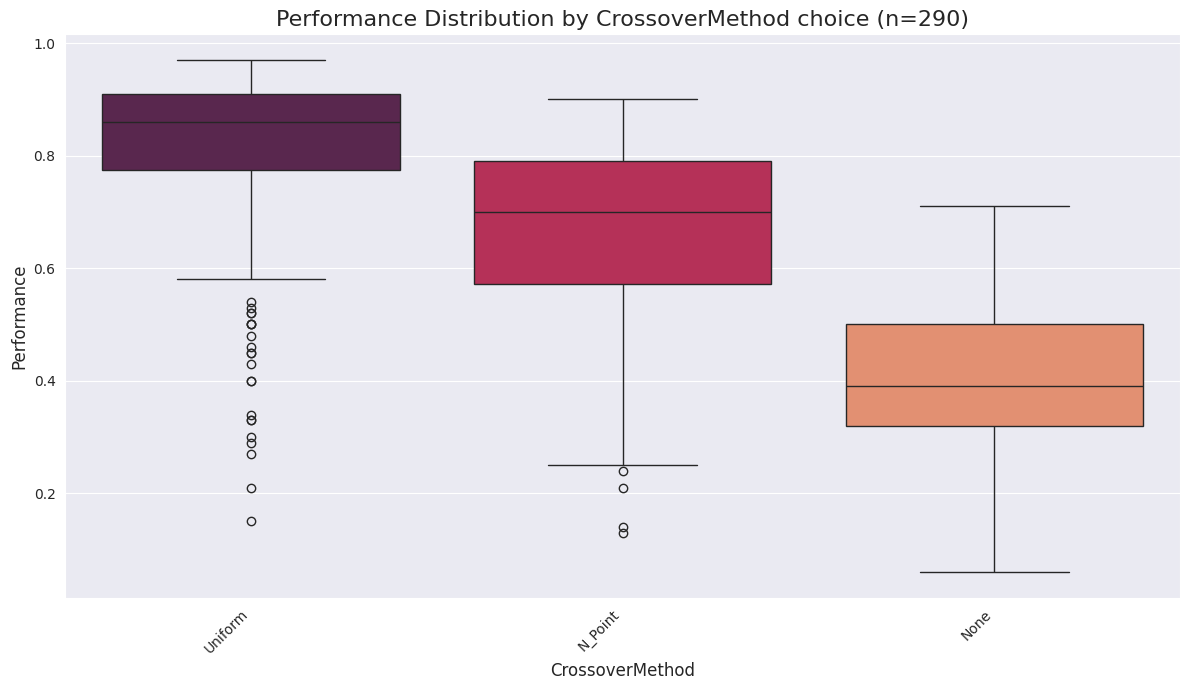


--- Performance Distribution by CrossoverMethod ---
                 count      mean       std   min     25%   50%   75%   max
CrossoverMethod                                                           
Uniform          179.0  0.799888  0.171661  0.15  0.7750  0.86  0.91  0.97
N_Point           90.0  0.653556  0.188985  0.13  0.5725  0.70  0.79  0.90
None              21.0  0.411429  0.182162  0.06  0.3200  0.39  0.50  0.71

--- Plotting Initialization vs. Value ---


/tmp/ipython-input-13-335547265.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df_categorical, x=categorical_feature, y='Value', order=cat_order, palette='rocket')


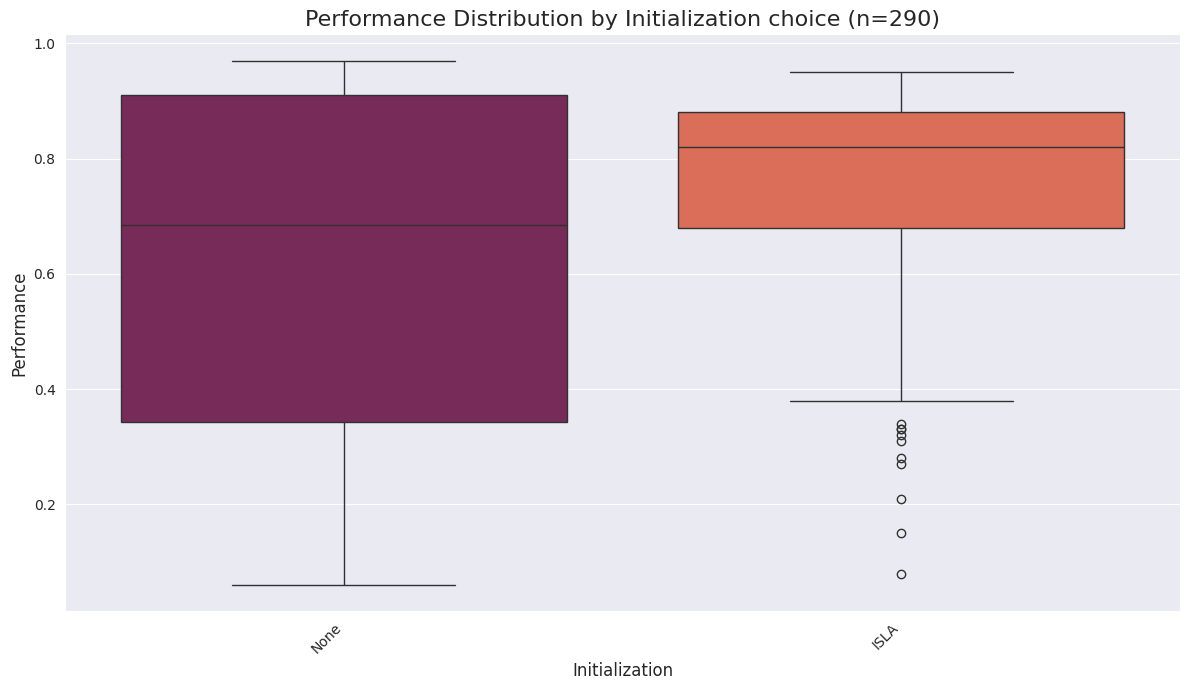


--- Performance Distribution by Initialization ---
                count      mean       std   min     25%    50%   75%   max
Initialization                                                            
None             54.0  0.617778  0.295786  0.06  0.3425  0.685  0.91  0.97
ISLA            236.0  0.751186  0.174990  0.08  0.6800  0.820  0.88  0.95

--- Plotting FitnessFunction vs. Value ---


/tmp/ipython-input-13-335547265.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df_categorical, x=categorical_feature, y='Value', order=cat_order, palette='rocket')


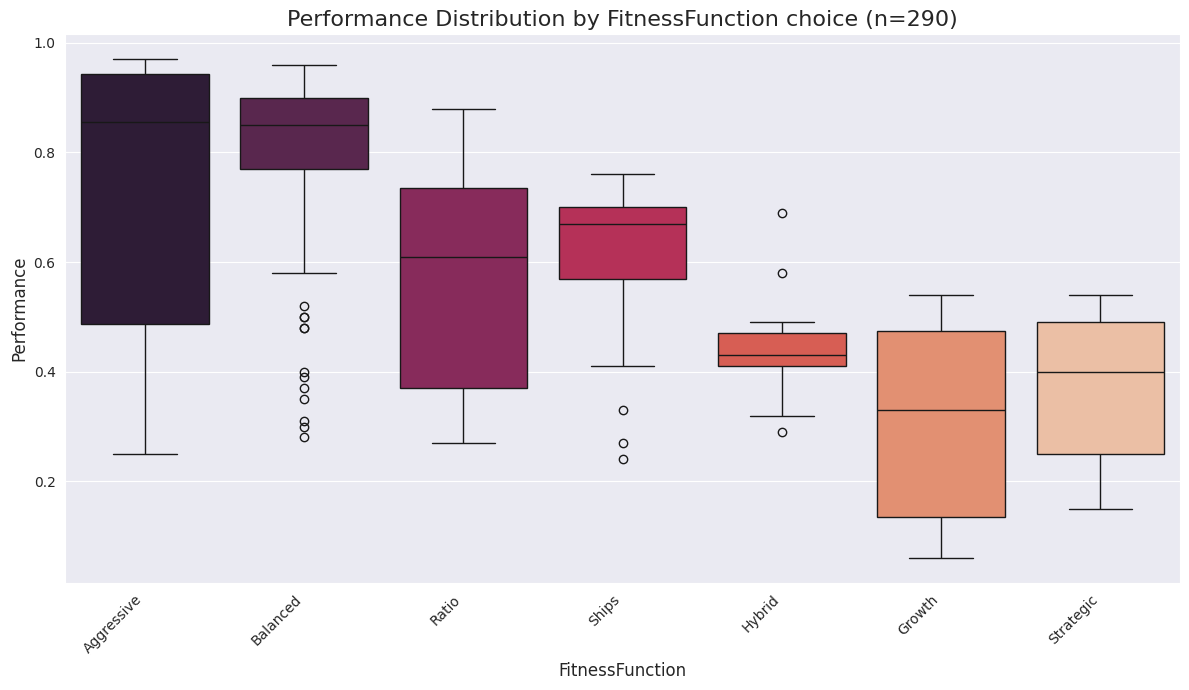


--- Performance Distribution by FitnessFunction ---
                 count      mean       std   min     25%    50%     75%   max
FitnessFunction                                                              
Aggressive        18.0  0.708889  0.268786  0.25  0.4875  0.855  0.9425  0.97
Balanced         199.0  0.812161  0.130770  0.28  0.7700  0.850  0.9000  0.96
Ratio             11.0  0.571818  0.220763  0.27  0.3700  0.610  0.7350  0.88
Ships             29.0  0.606552  0.138726  0.24  0.5700  0.670  0.7000  0.76
Hybrid            11.0  0.449091  0.110856  0.29  0.4100  0.430  0.4700  0.69
Growth            11.0  0.309091  0.180857  0.06  0.1350  0.330  0.4750  0.54
Strategic         11.0  0.367273  0.140006  0.15  0.2500  0.400  0.4900  0.54

--- Plotting MutationMethod vs. Value ---


/tmp/ipython-input-13-335547265.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df_categorical, x=categorical_feature, y='Value', order=cat_order, palette='rocket')


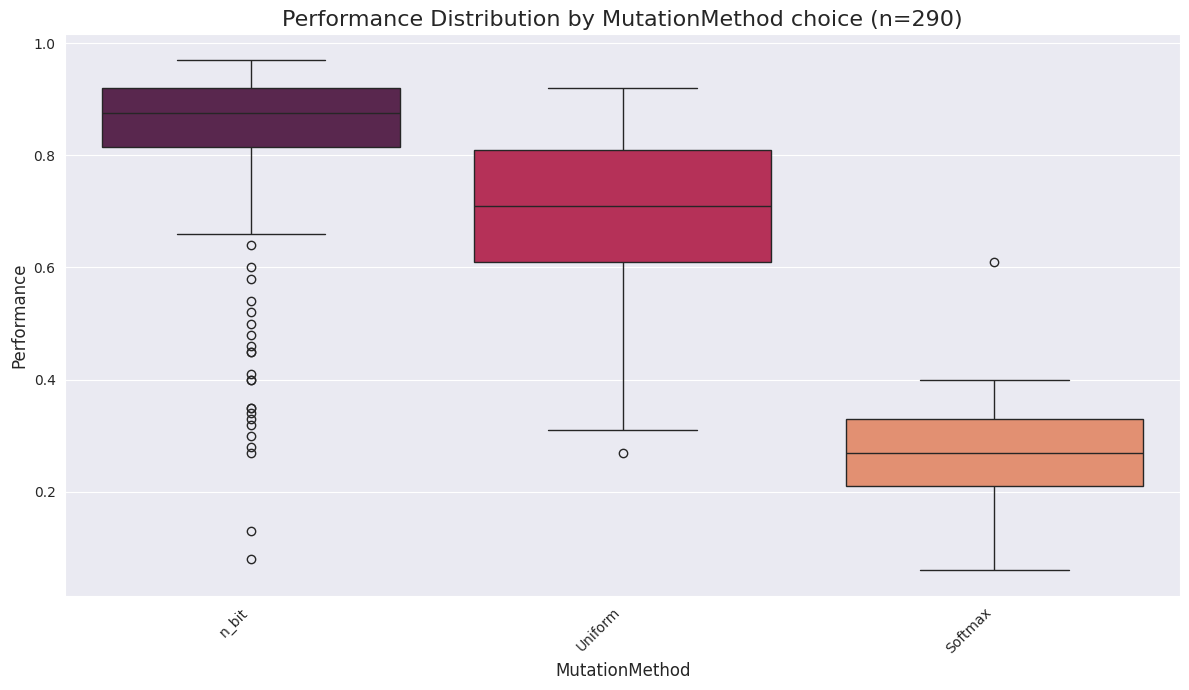


--- Performance Distribution by MutationMethod ---
                count      mean       std   min    25%    50%   75%   max
MutationMethod                                                           
n_bit           152.0  0.802961  0.188602  0.08  0.815  0.875  0.92  0.97
Uniform         123.0  0.686341  0.154141  0.27  0.610  0.710  0.81  0.92
Softmax          15.0  0.278000  0.131214  0.06  0.210  0.270  0.33  0.61

--- Plotting ParentSelectionStrategy vs. Value ---


/tmp/ipython-input-13-335547265.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df_categorical, x=categorical_feature, y='Value', order=cat_order, palette='rocket')


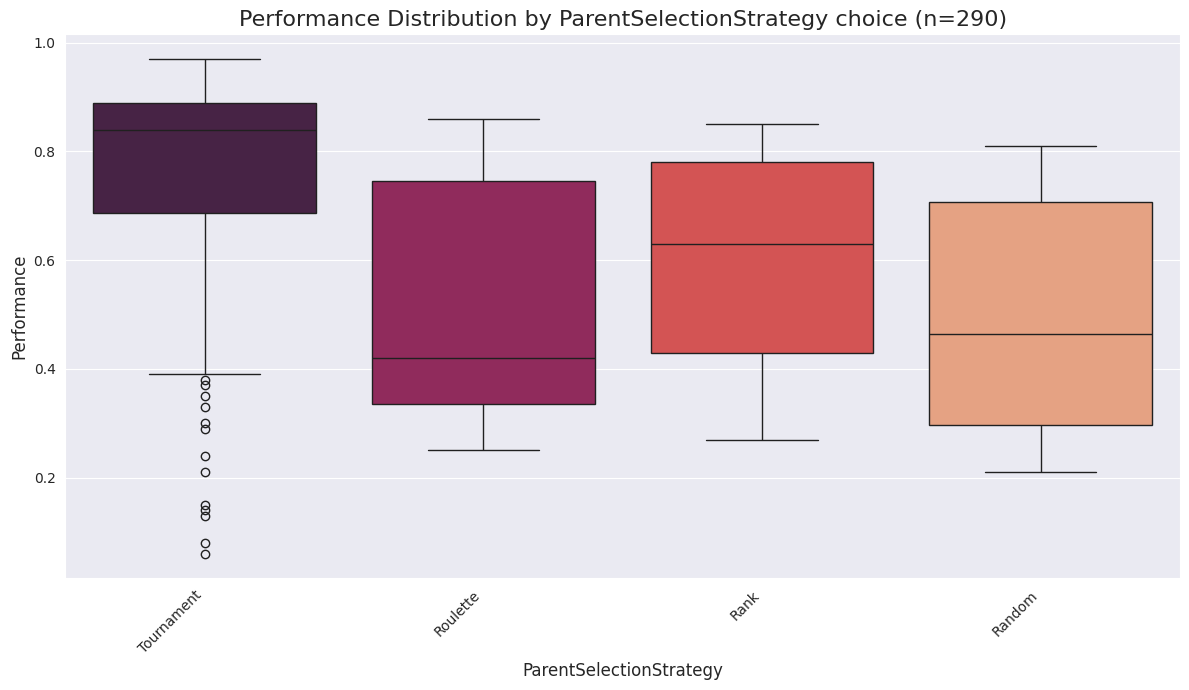


--- Performance Distribution by ParentSelectionStrategy ---
                         count      mean       std   min     25%    50%  \
ParentSelectionStrategy                                                   
Tournament               244.0  0.761352  0.188994  0.06  0.6875  0.840   
Roulette                  15.0  0.517333  0.217764  0.25  0.3350  0.420   
Rank                      17.0  0.601176  0.207512  0.27  0.4300  0.630   
Random                    14.0  0.492143  0.213764  0.21  0.2975  0.465   

                            75%   max  
ParentSelectionStrategy                
Tournament               0.8900  0.97  
Roulette                 0.7450  0.86  
Rank                     0.7800  0.85  
Random                   0.7075  0.81  


In [14]:
use_trials=['1000TicksAllParameters']

# Identify all categorical features in the dataframe (excluding 'source' and 'State')
all_categorical_params = [col for col in df.columns if df[col].dtype == 'object' and col not in ['source', 'State', 'Duration']]

if all_categorical_params:
    print("Generating plots for all categorical parameters:")
    for param in all_categorical_params:
        print(f"\n--- Plotting {param} vs. Value ---")
        plot_categorical_feature_vs_value(df, param, use_trials)
else:
    print("No categorical parameters found in the dataframe.")


--- Analyzing Population Size vs. Sequence Length for the 2 Largest Trials (n=290) ---
Sources: ['db_1000TicksAllParameters']


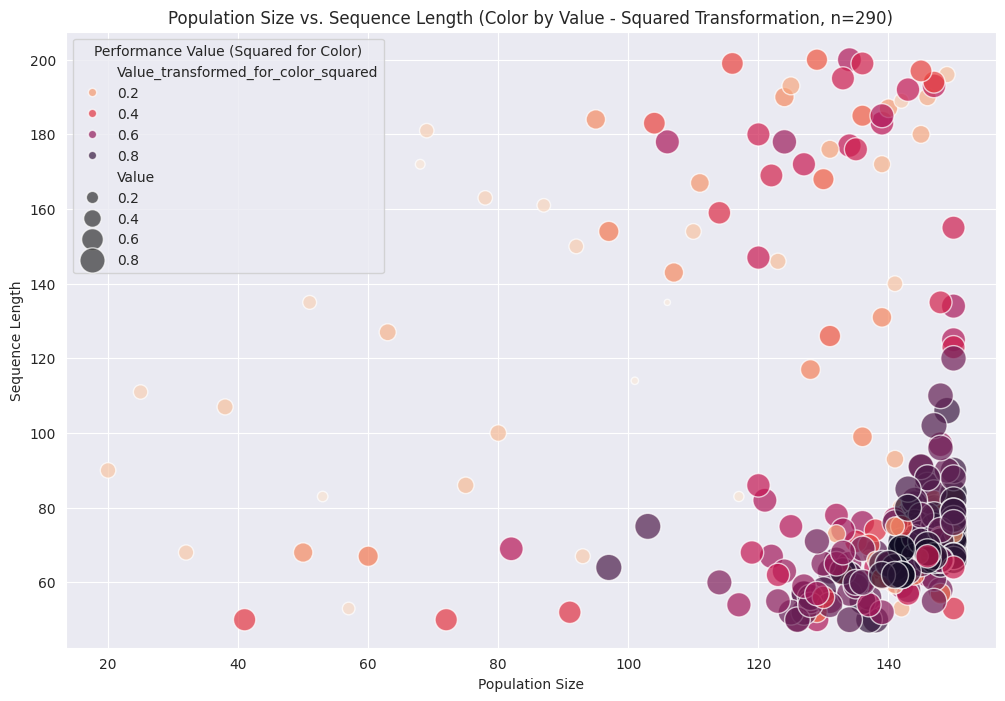

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Use the existing DataFrame 'df'
# Apply a transformation to 'Value' specifically for color mapping to emphasize higher values
df['Value_transformed_for_color_squared'] = df['Value']**2

use_trials=['1000TicksAllParameters']

# Filter df to include only the trials specified in use_trials
analysis_df = df[df['source'].apply(lambda x: any(trial_name in x for trial_name in use_trials))].copy()

# c) Scatter plot for population vs sequenceLength for the two largest trials
if not analysis_df.empty:
    # Find the two largest sources (trials) within the analysis data
    filtered_study_summaries = analysis_df['source'].value_counts().index.tolist()
    if filtered_study_summaries:
        scatter_plot_df = analysis_df[analysis_df['source'].isin(filtered_study_summaries)].copy()

        scatter_sample_size = len(scatter_plot_df)

        print(f"\n--- Analyzing Population Size vs. Sequence Length for the 2 Largest Trials (n={scatter_sample_size}) ---")
        print(f"Sources: {filtered_study_summaries}")
        plt.figure(figsize=(12, 8))
        sns.set_style("darkgrid") # Set style to darkgrid for grey background
        sns.scatterplot(
            data=scatter_plot_df,
            x='PopulationSize',
            y='SequenceLength',
            size='Value', # Size still based on original Value
            hue='Value_transformed_for_color_squared', # Hue based on squared transformed Value
            sizes=(20, 400),
            palette='rocket_r', # Use rocket_r palette
            alpha=0.7
        )
        plt.title(f'Population Size vs. Sequence Length (Color by Value - Squared Transformation, n={scatter_sample_size})')
        plt.xlabel('Population Size')
        plt.ylabel('Sequence Length')
        # Update legend title to reflect the transformation
        plt.legend(title='Performance Value (Squared for Color)')
        plt.show()


--- Analyzing Trial Duration (n=290) ---

Generating scatter plots for continuous features vs. Duration:


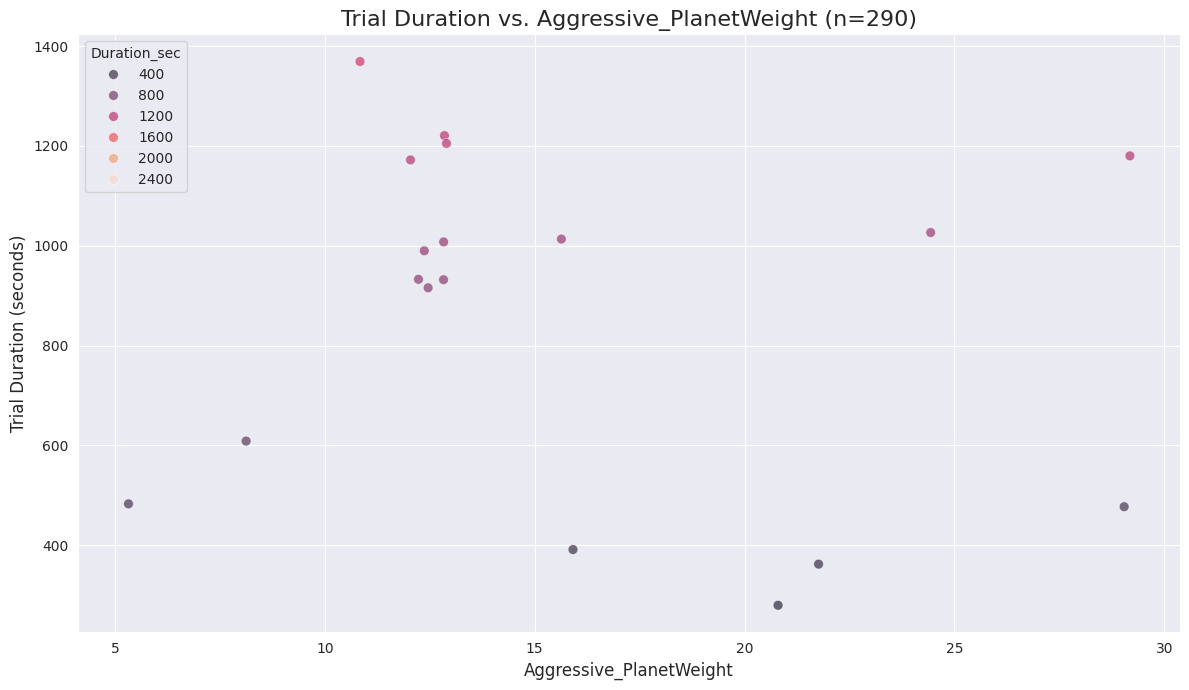

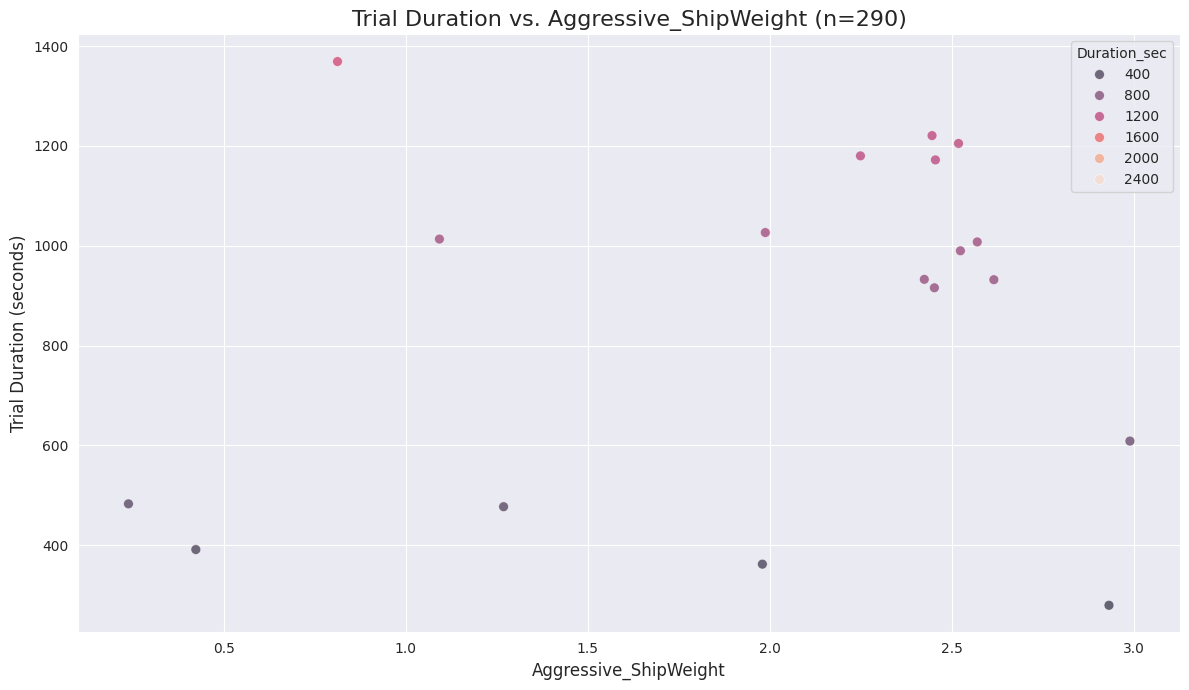

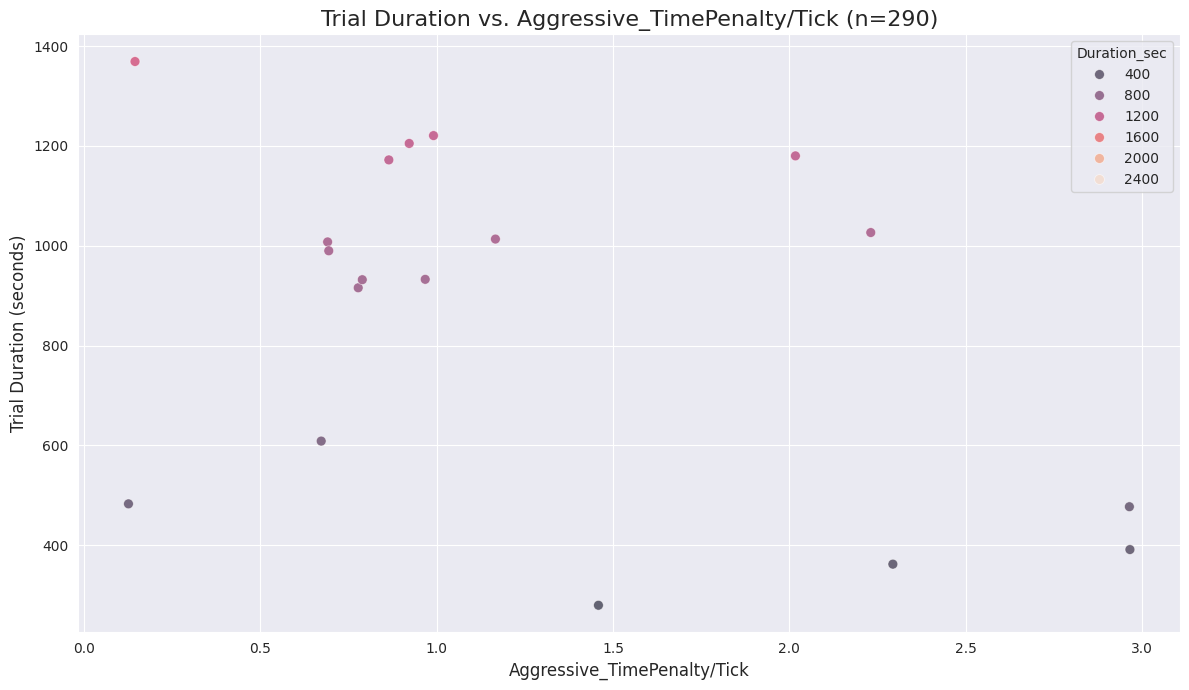

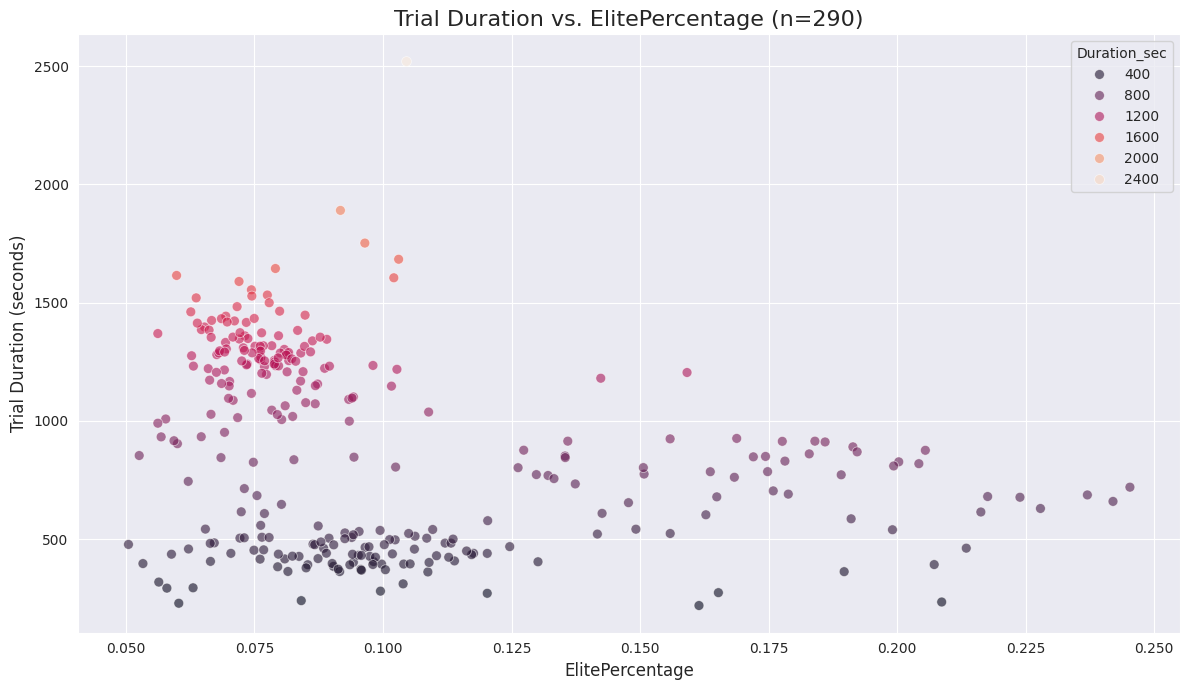

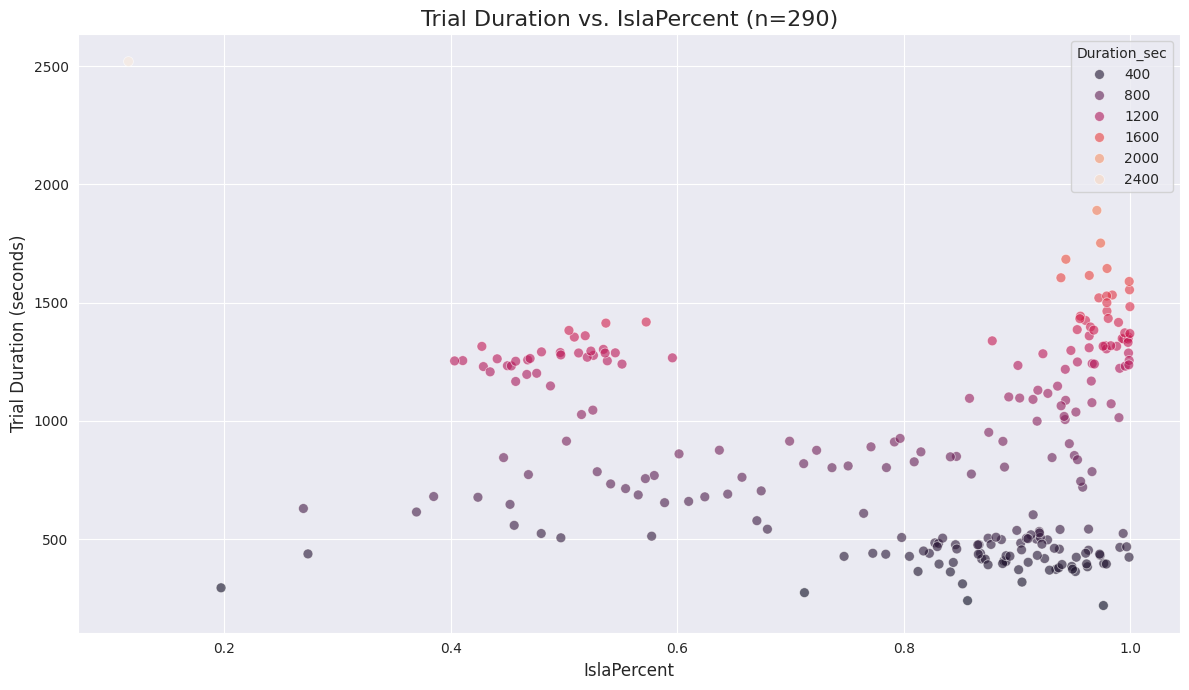

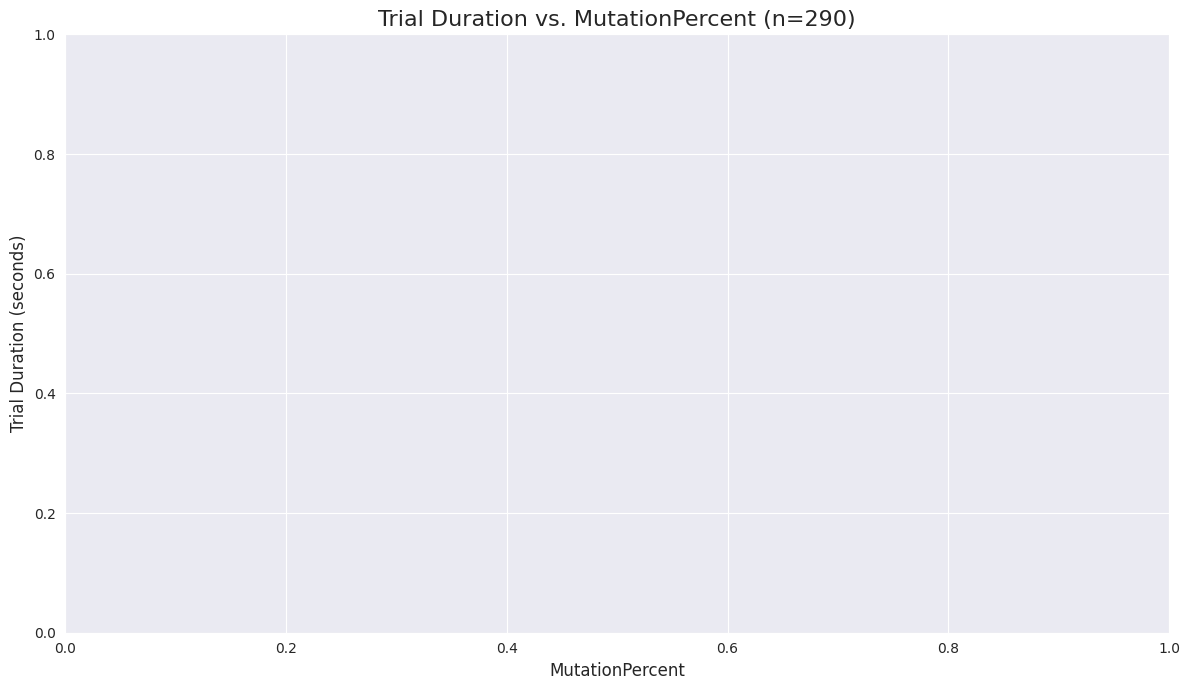

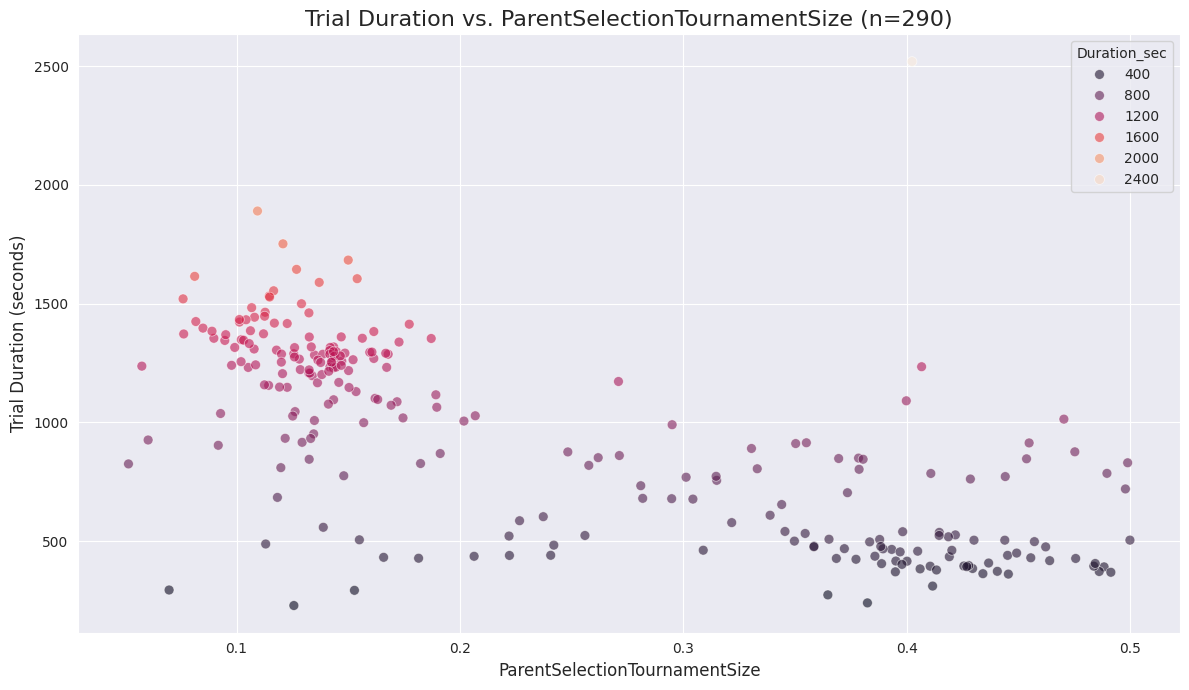

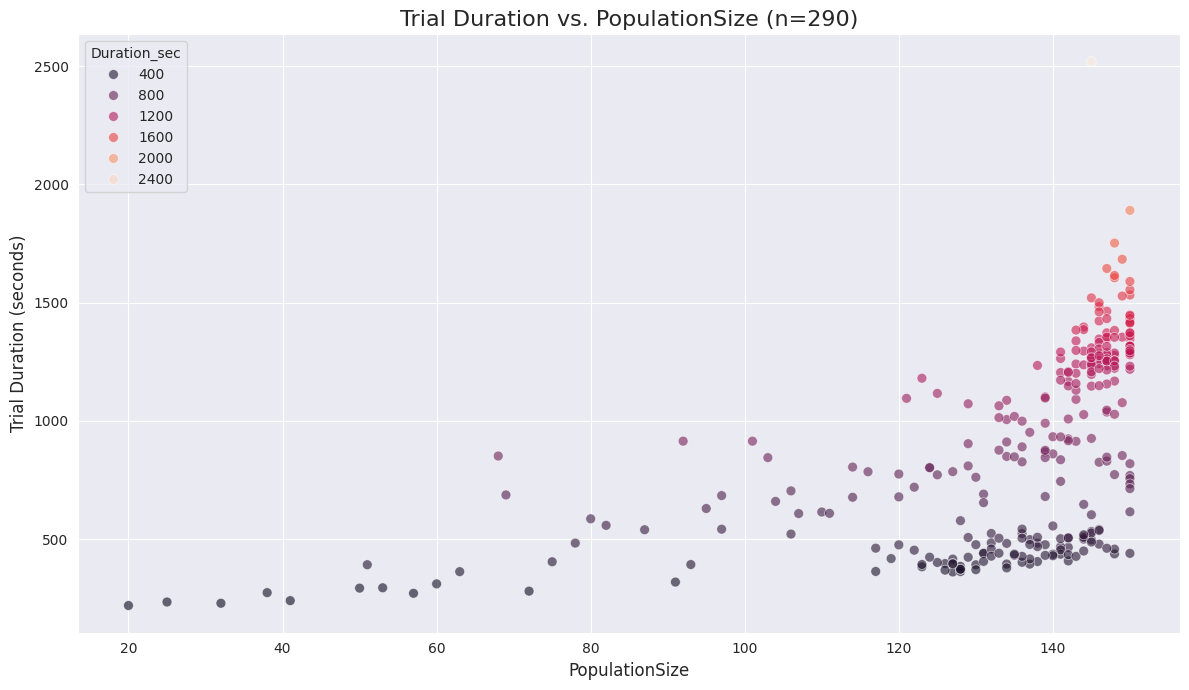

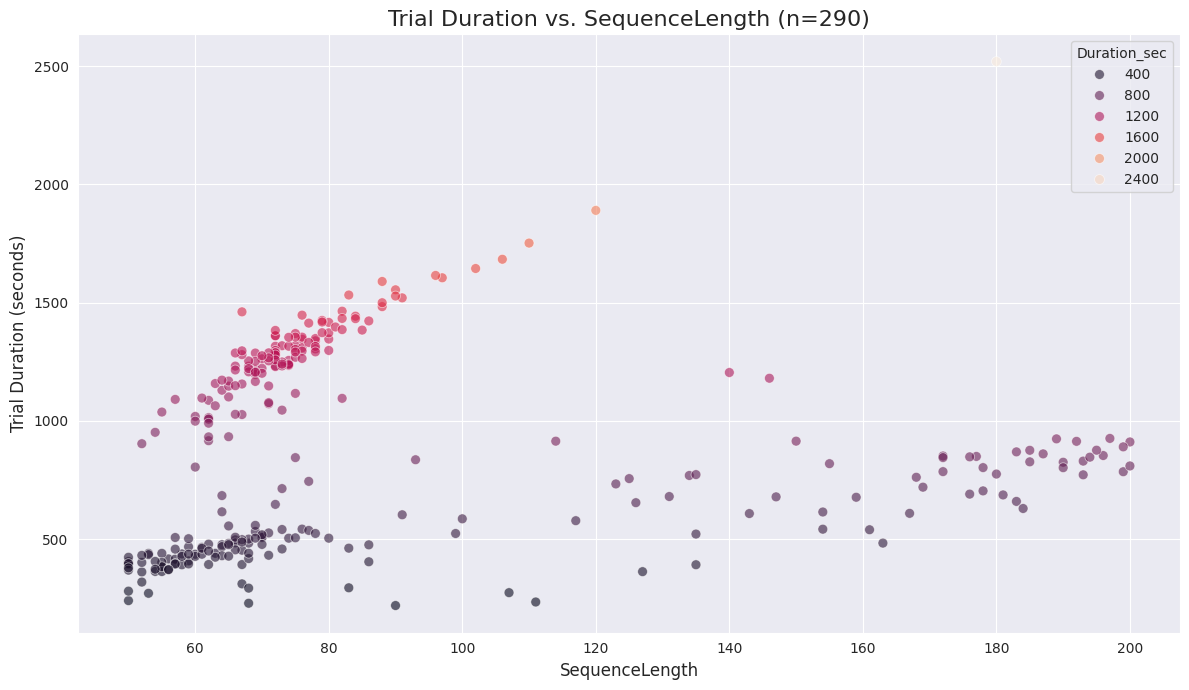

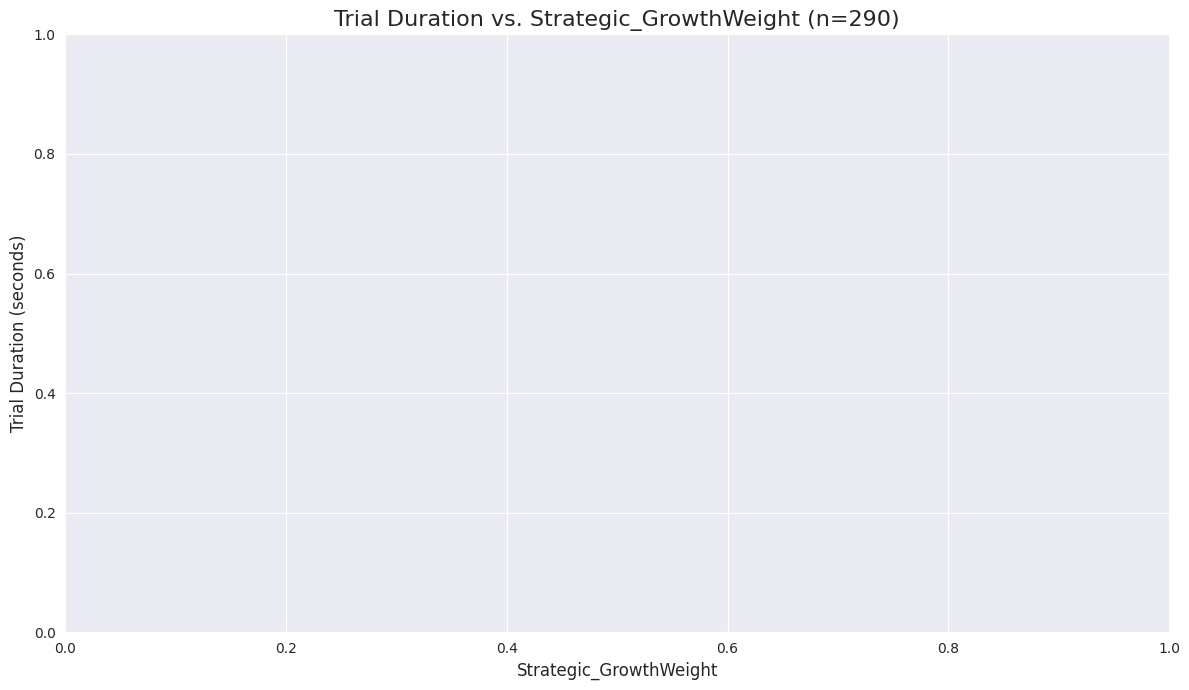

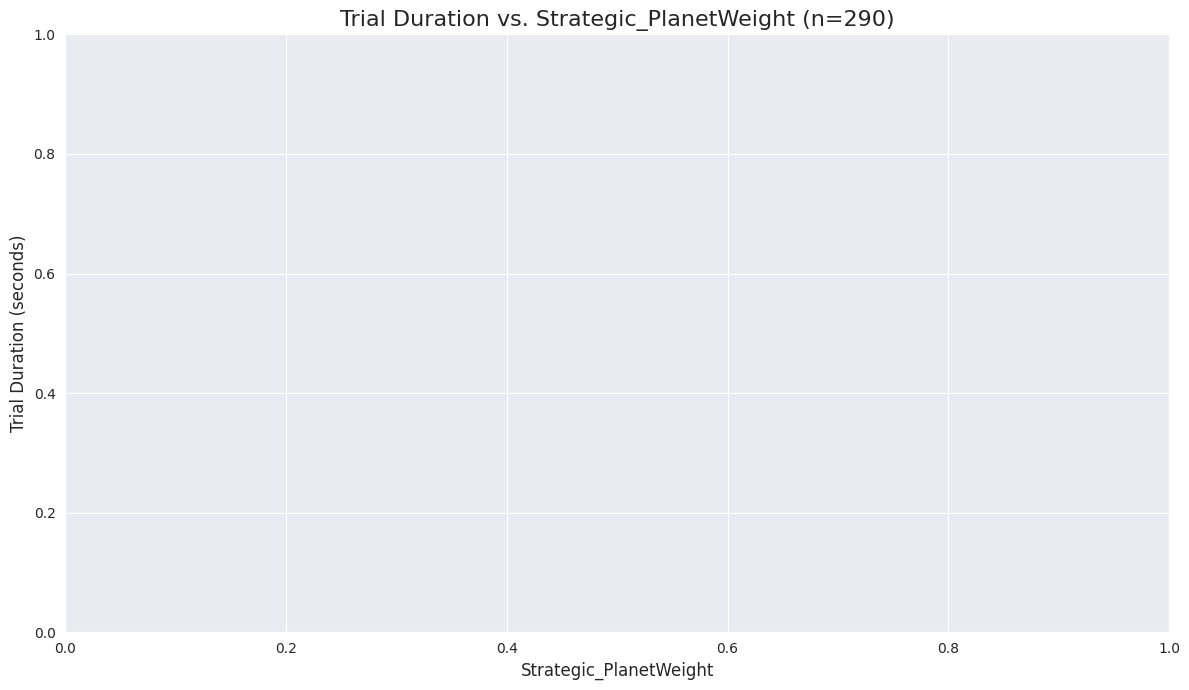

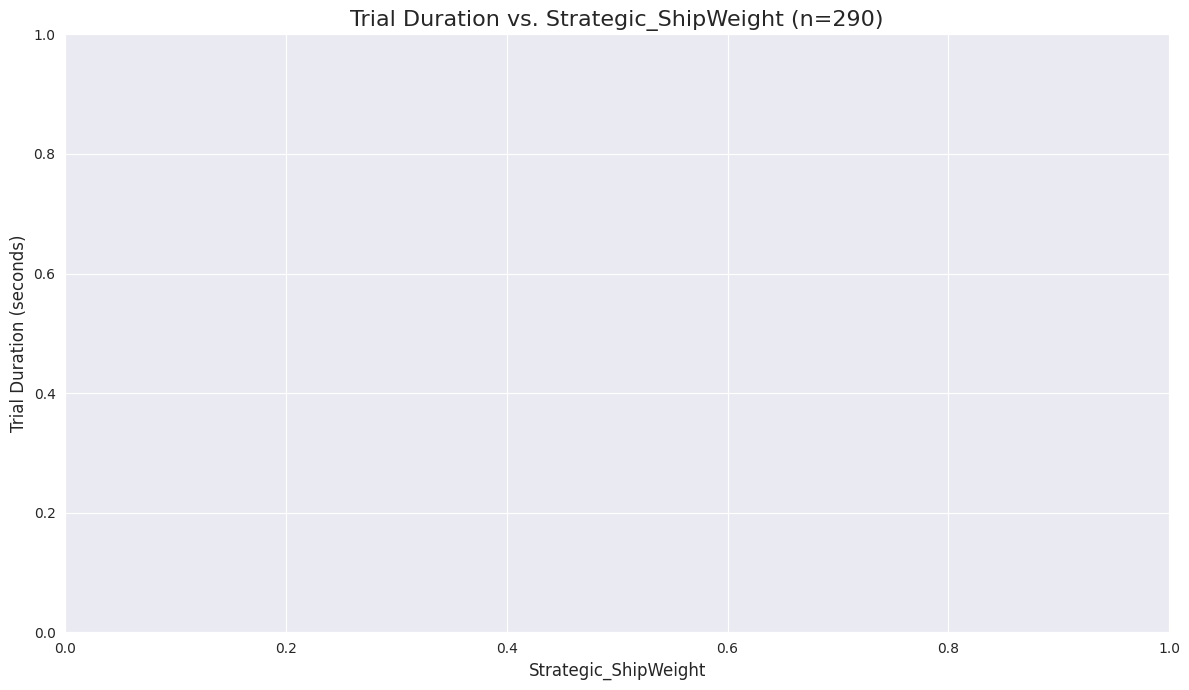

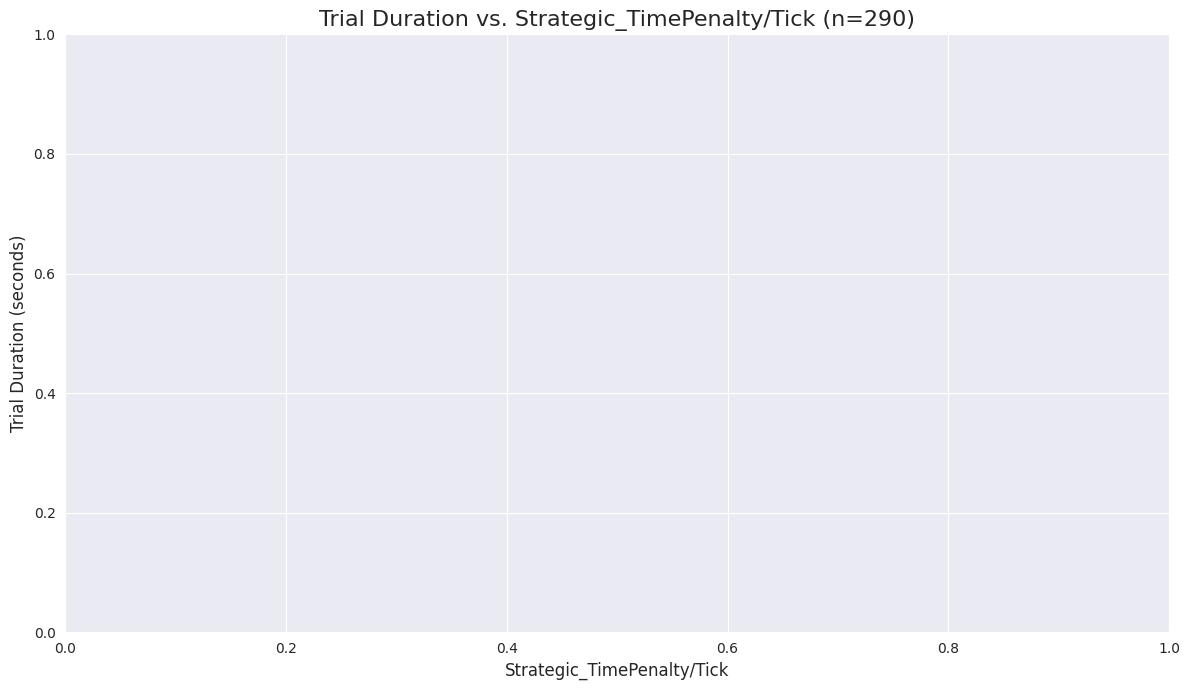

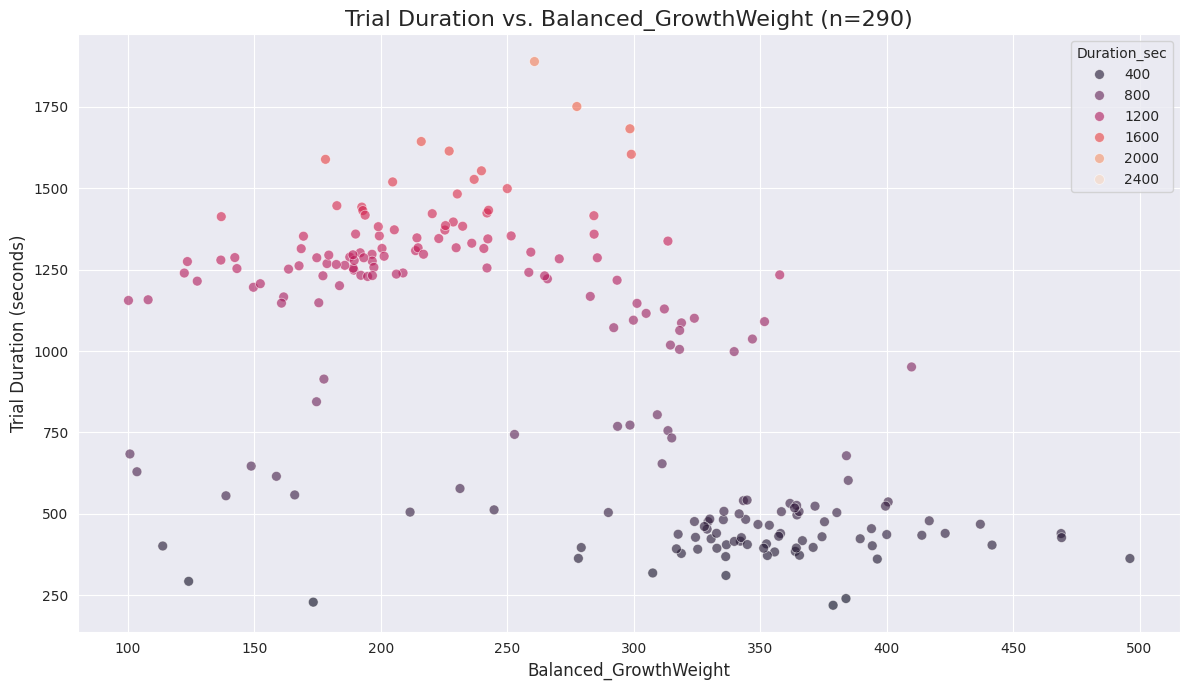

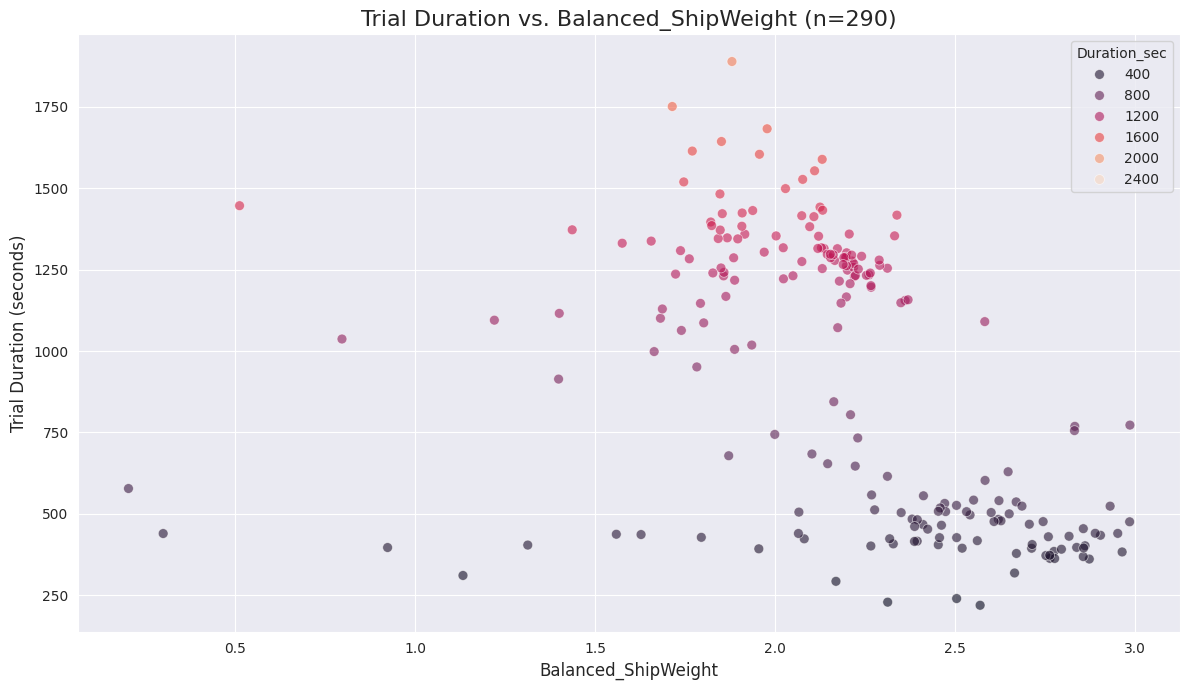

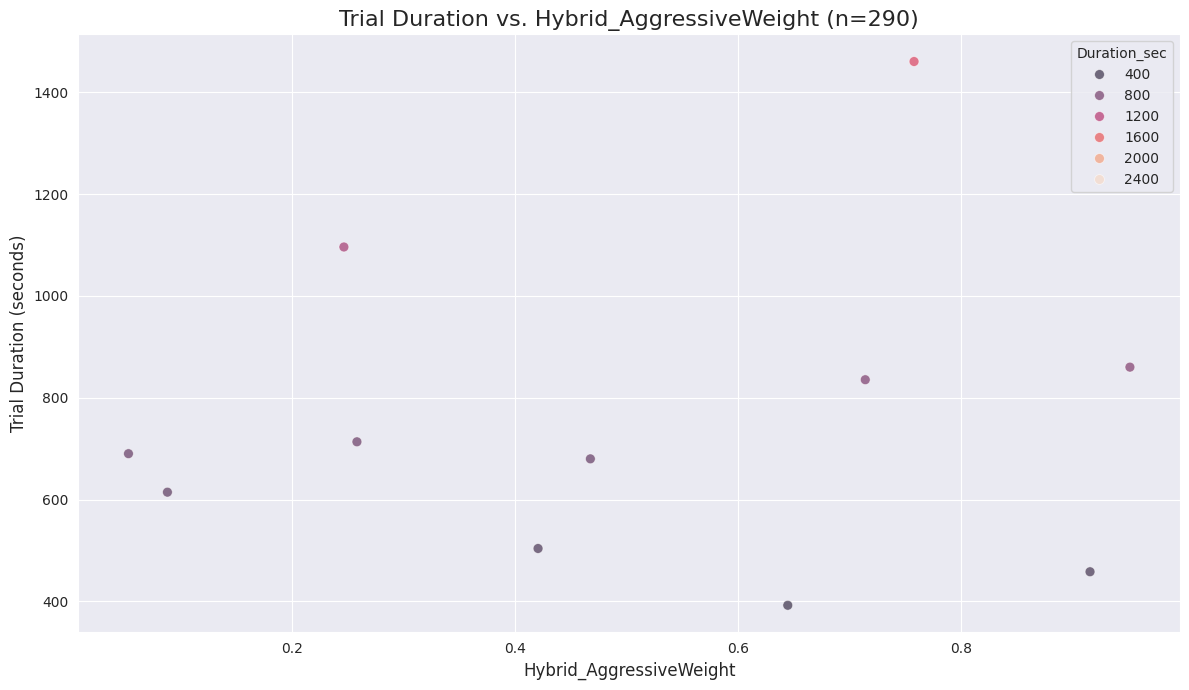

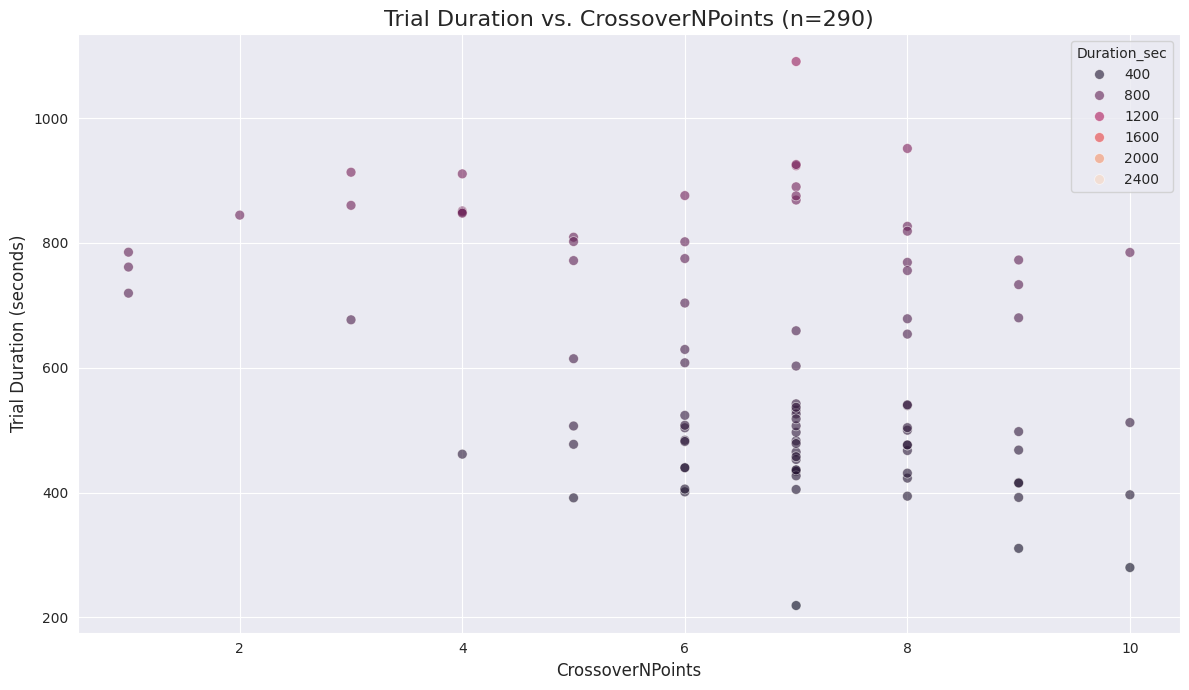

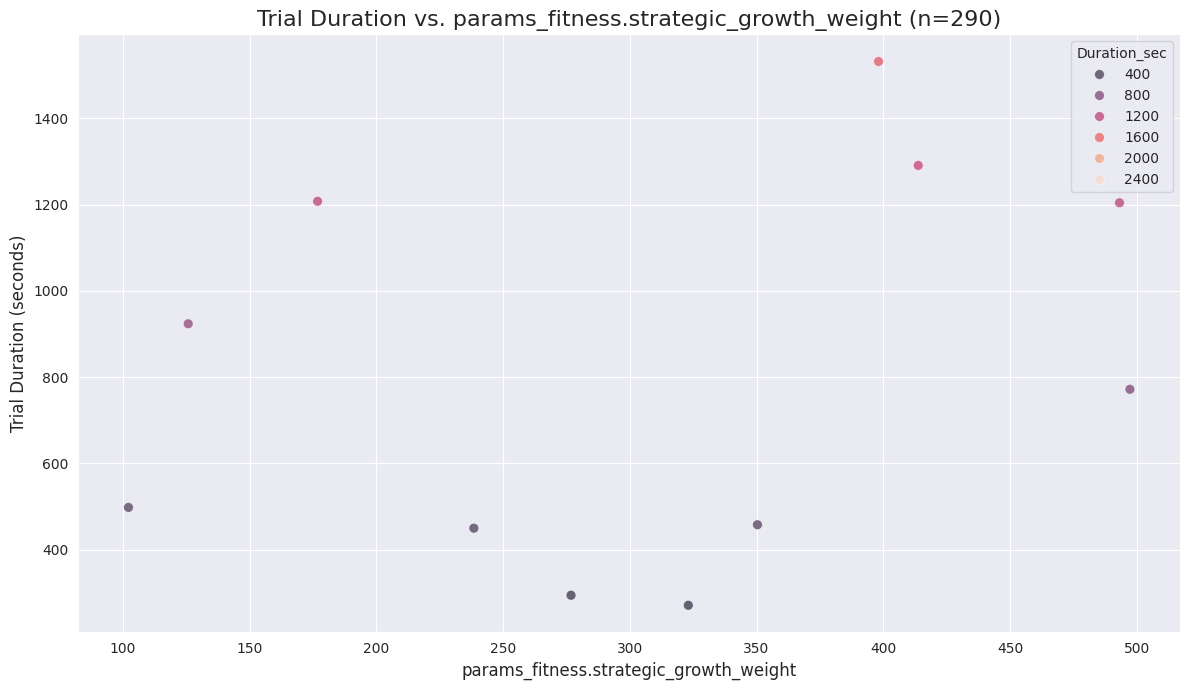

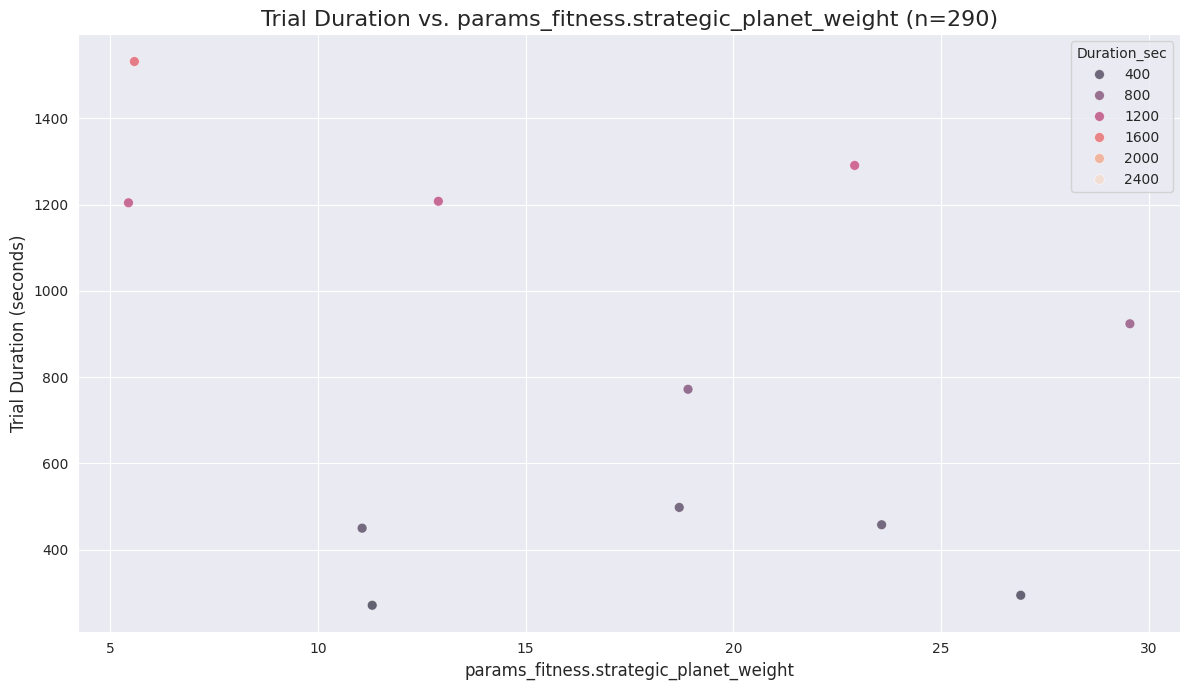

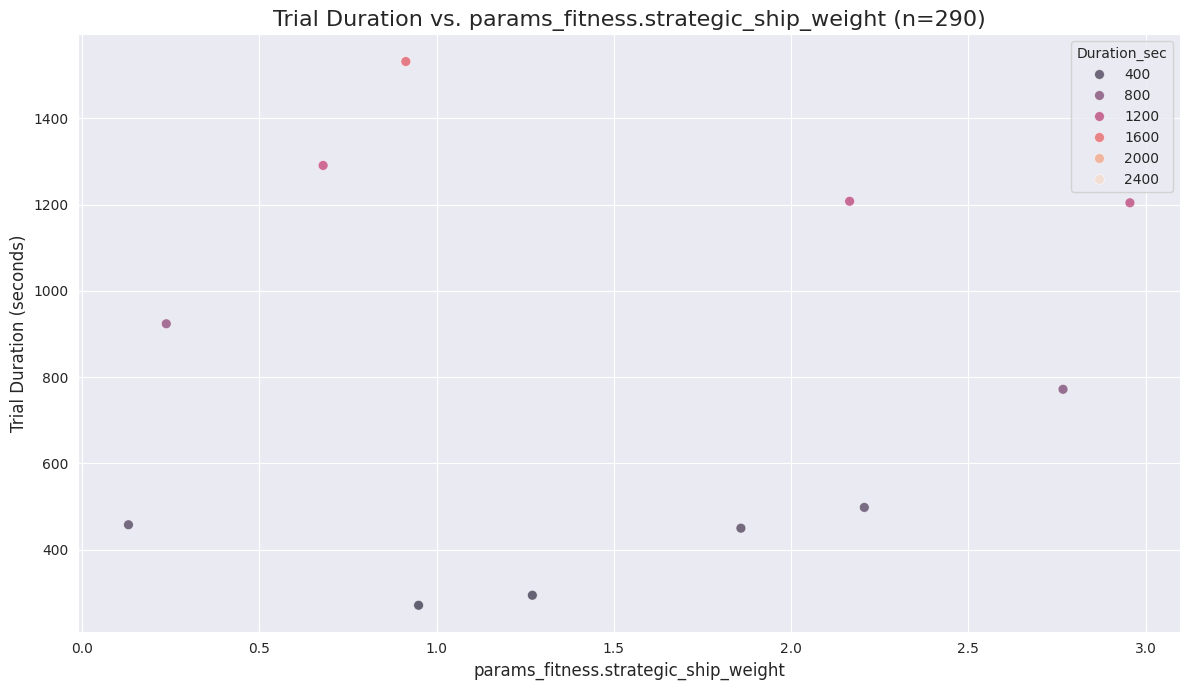

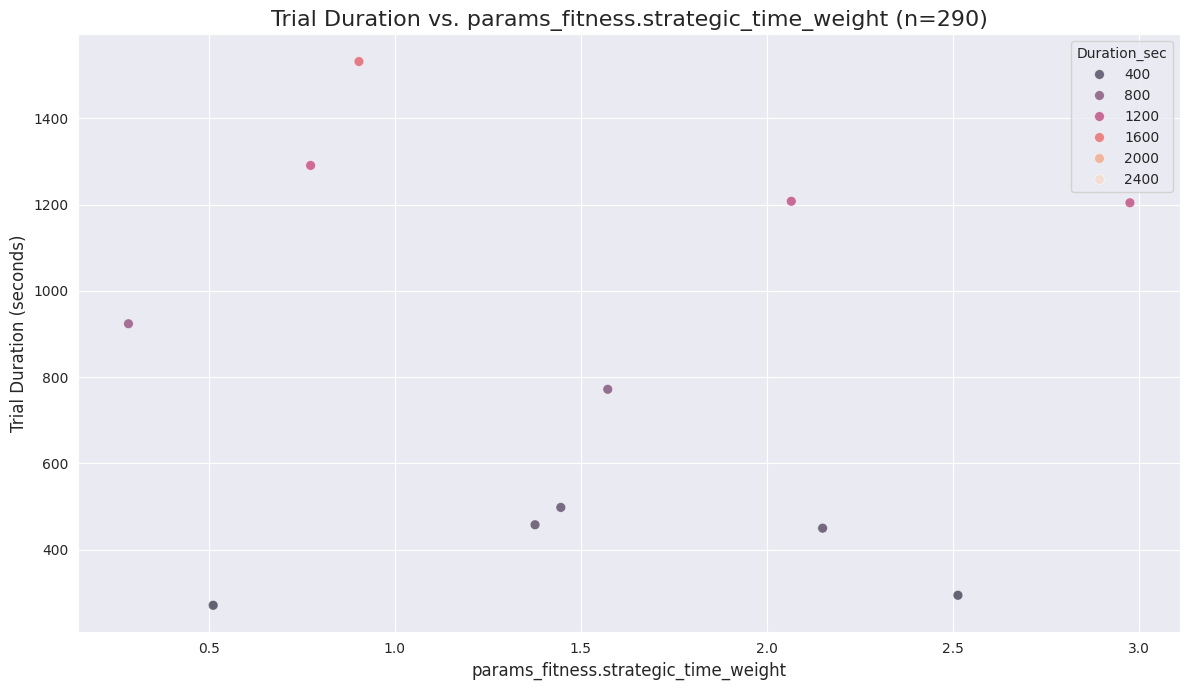

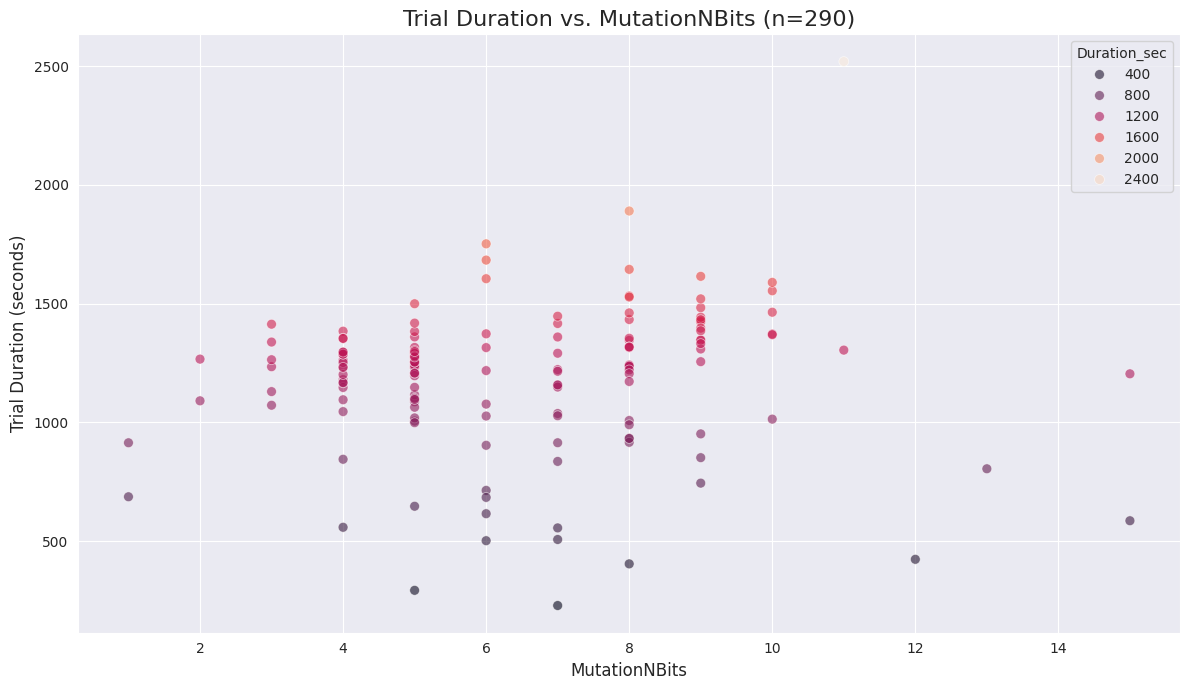

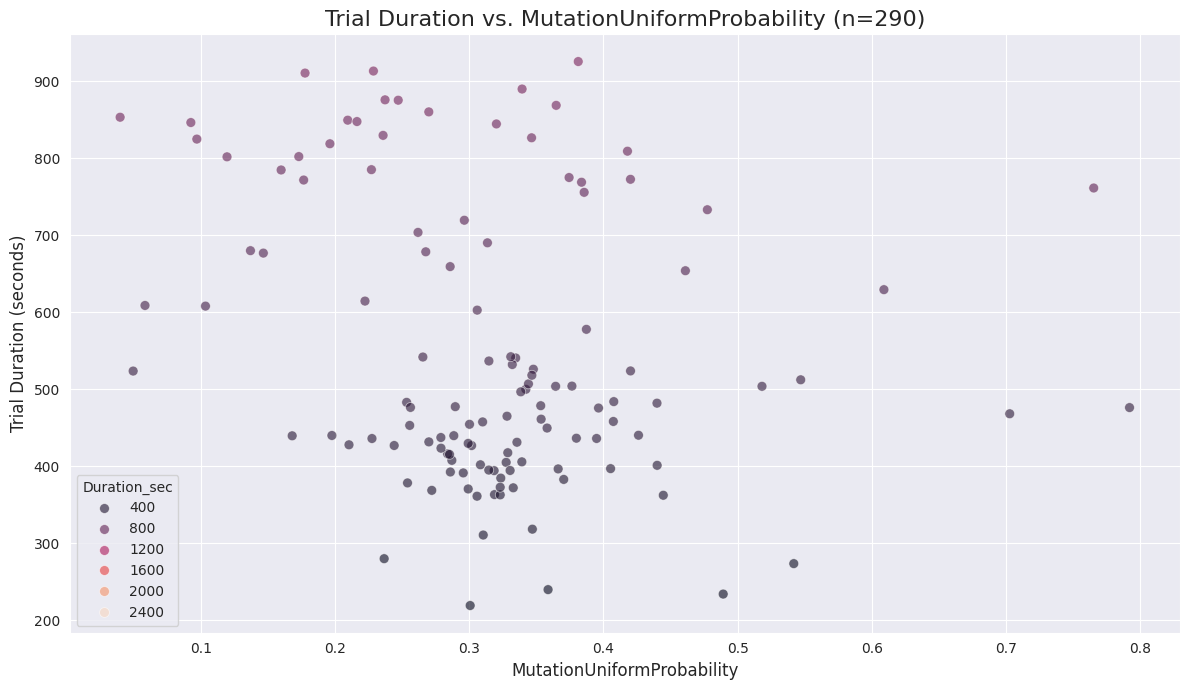

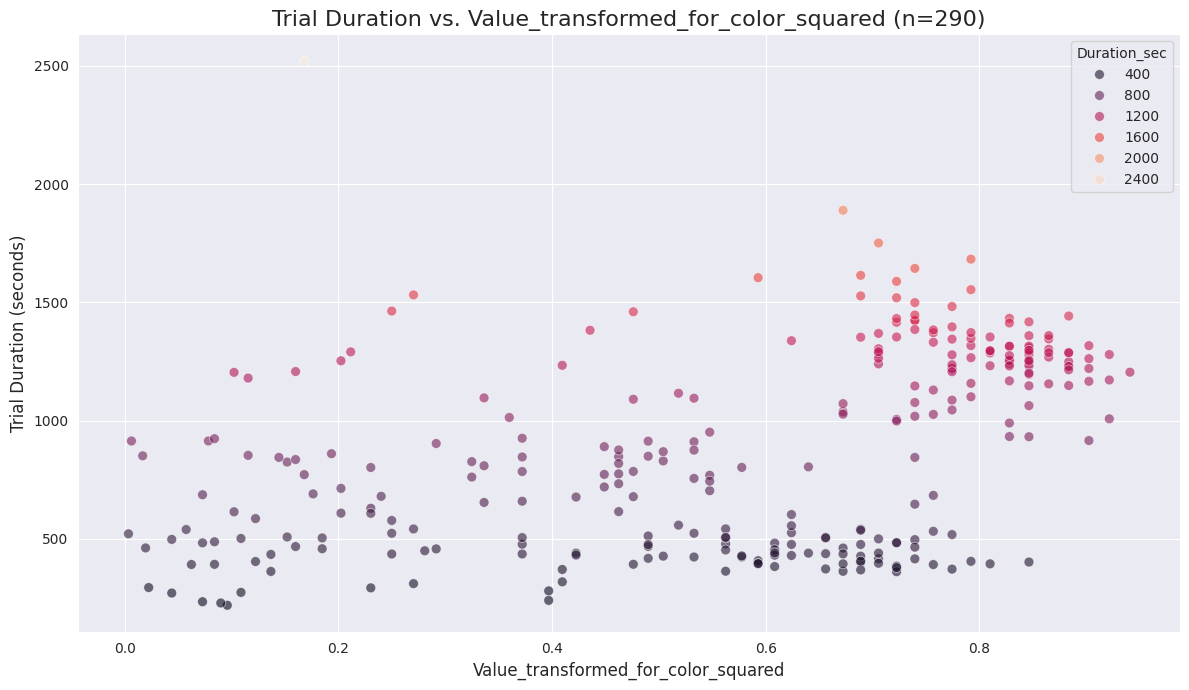


Generating box plots for categorical features vs. Duration:


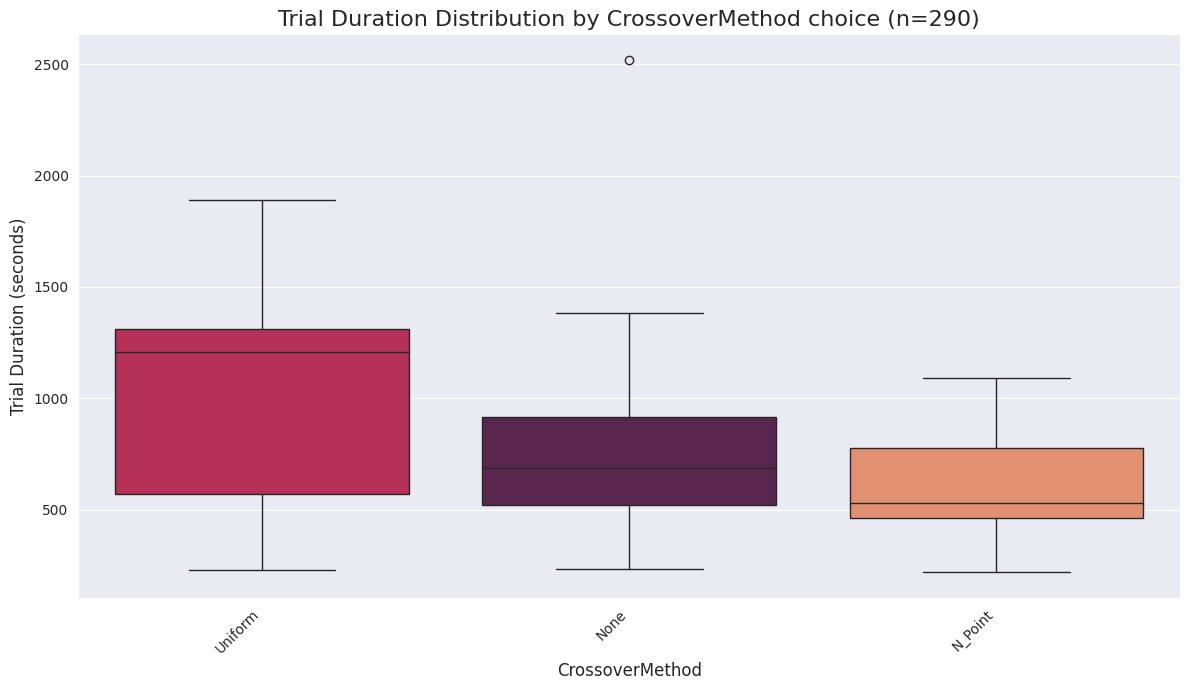

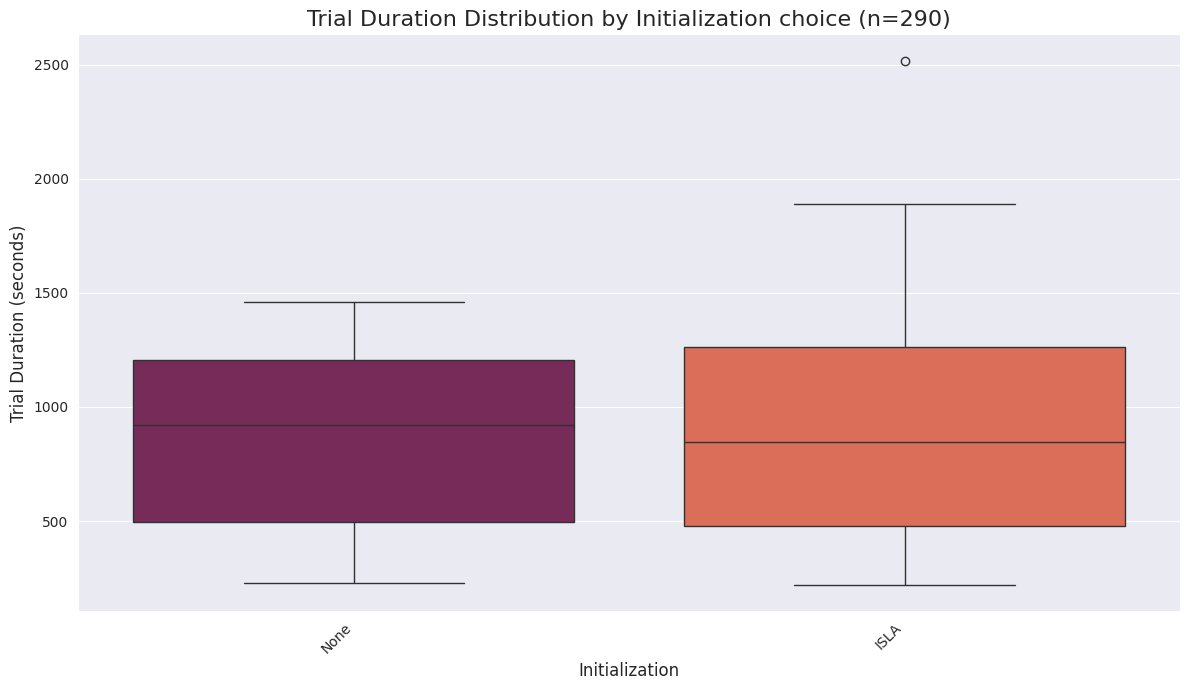

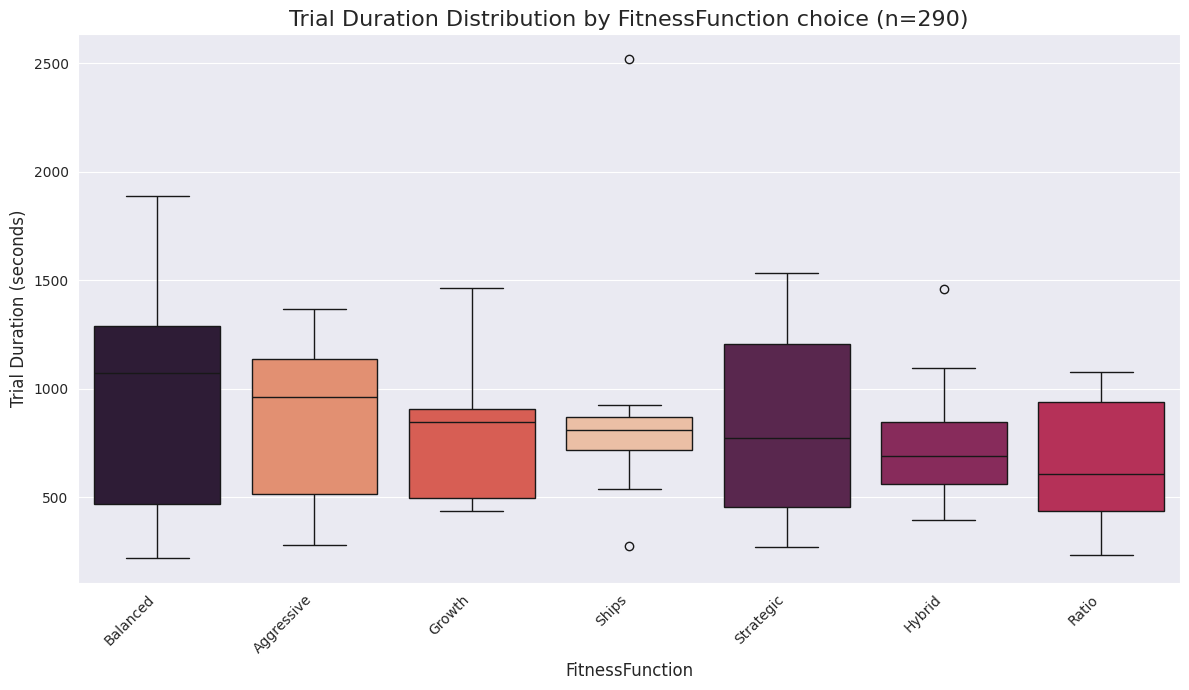

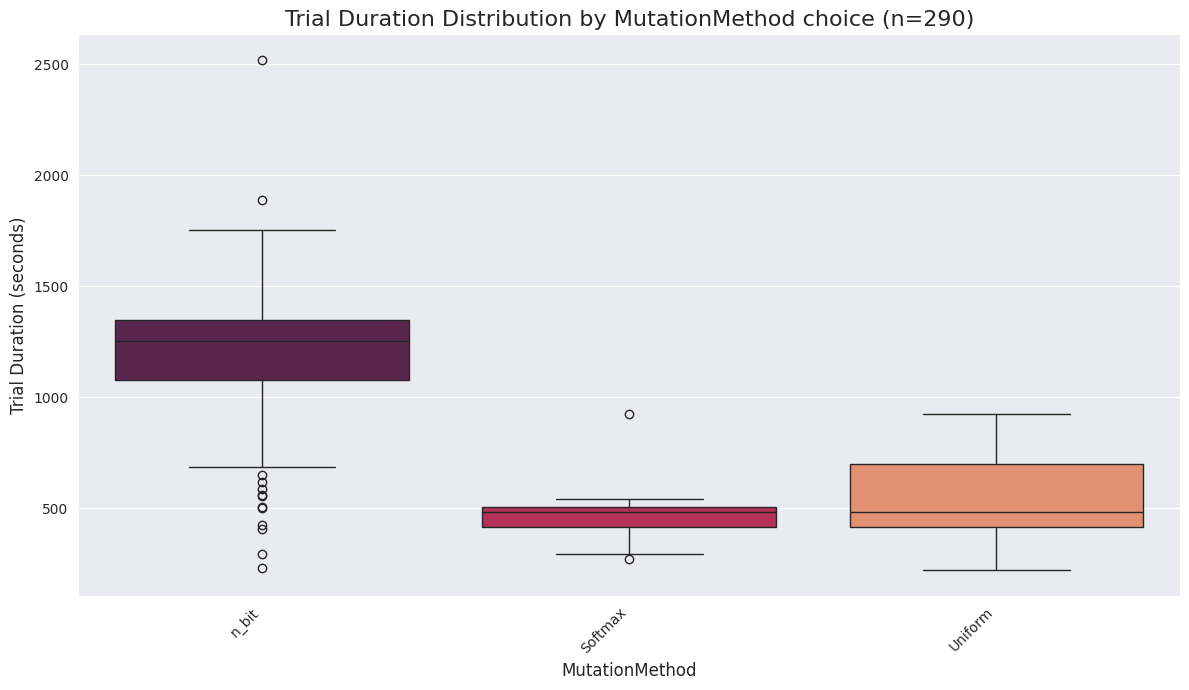

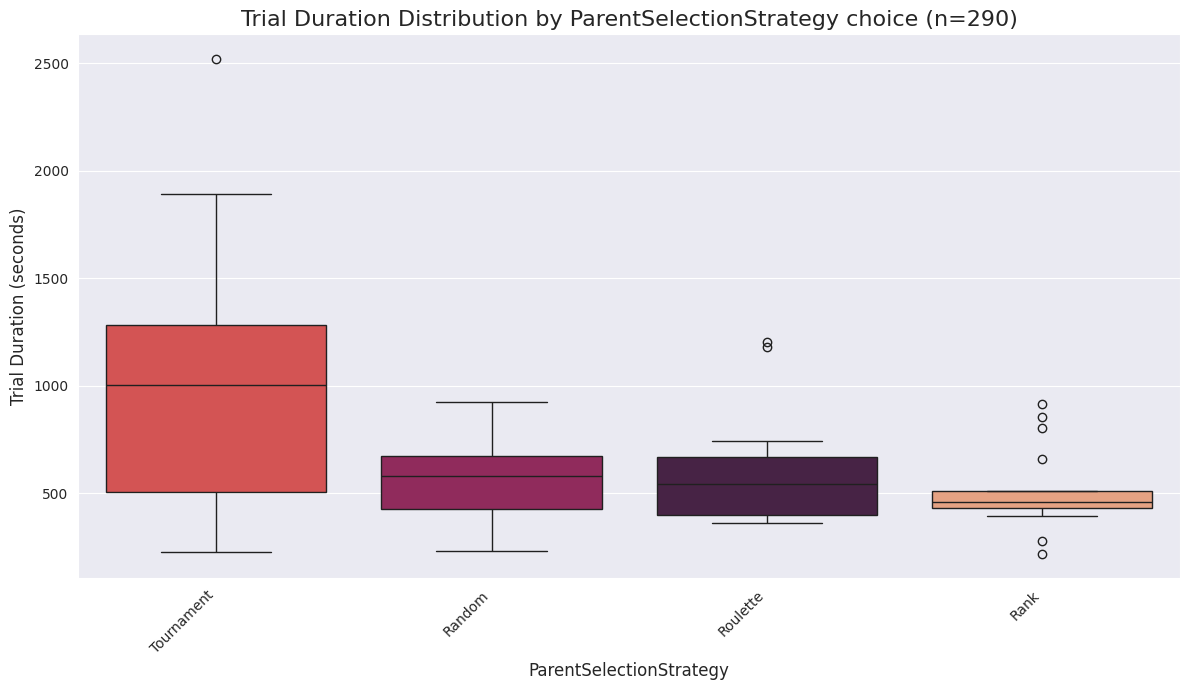

In [16]:
# Define the list of trials to include in the analysis
use_trials_duration = ['1000TicksAllParameters'] # Adjust as needed

# Filter the main dataframe based on the selected trials and ensure 'Duration_sec' is not null
analysis_df_duration = df[df['source'].apply(lambda x: any(trial_name in x for trial_name in use_trials_duration))].copy()
analysis_df_duration = analysis_df_duration.dropna(subset=['Duration_sec']).copy()


if not analysis_df_duration.empty:
    print(f"\n--- Analyzing Trial Duration (n={analysis_df_duration.shape[0]}) ---")

    # Identify all continuous and categorical features in the filtered dataframe
    all_features = [col for col in analysis_df_duration.columns if col not in ['Number', 'Value', 'datetime_start', 'datetime_complete', 'Duration', 'State', 'source', 'Duration_sec']]
    continuous_features_duration = [col for col in all_features if pd.api.types.is_numeric_dtype(analysis_df_duration[col])]
    categorical_features_duration = [col for col in all_features if analysis_df_duration[col].dtype == 'object']

    # Plotting Continuous Features vs. Duration
    if continuous_features_duration:
        print("\nGenerating scatter plots for continuous features vs. Duration:")
        for feature in continuous_features_duration:
            plt.figure(figsize=(12, 7))
            sns.set_style("darkgrid")
            sns.scatterplot(data=analysis_df_duration, x=feature, y='Duration_sec', alpha=0.6, s=50, hue='Duration_sec', palette='rocket')
            plt.title(f'Trial Duration vs. {feature} (n={analysis_df_duration.shape[0]})', fontsize=16)
            plt.xlabel(feature, fontsize=12)
            plt.ylabel('Trial Duration (seconds)', fontsize=12)
            plt.tight_layout()
            plt.show()

    else:
        print("\nNo continuous features found for duration analysis.")

    # Plotting Categorical Features vs. Duration
    if categorical_features_duration:
        print("\nGenerating box plots for categorical features vs. Duration:")
        for feature in categorical_features_duration:
             if analysis_df_duration[feature].nunique() > 1:
                plt.figure(figsize=(12, 7))
                sns.set_style("darkgrid")
                # Sort categories by median duration for better visualization
                cat_order_dur = analysis_df_duration.groupby(feature)['Duration_sec'].median().sort_values(ascending=False).index
                sns.boxplot(data=analysis_df_duration, x=feature, y='Duration_sec', order=cat_order_dur, palette='rocket', hue=feature, legend=False) # Added hue and legend=False
                plt.title(f'Trial Duration Distribution by {feature} choice (n={analysis_df_duration.shape[0]})', fontsize=16)
                plt.xlabel(feature, fontsize=12)
                plt.ylabel('Trial Duration (seconds)', fontsize=12)
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                plt.show()
             else:
                print(f"\nSkipping box plot for '{feature}': Not enough unique values.")

else:
    print("\nNo data with non-null 'Duration_sec' in the filtered data to analyze duration.")

In [17]:
import optuna

# Specify the path to your Optuna database
db_path = 'db.sqlite3'
storage_url = f"sqlite:///{db_path}"

try:
    # Create an RDBStorage object
    storage = optuna.storages.RDBStorage(url=f"sqlite:///{db_path}")

    # Get summaries of all studies in the database
    all_study_summaries = optuna.study.get_all_study_summaries(storage)

    if not all_study_summaries:
        print(f"No studies found in the database at '{db_path}'.")
    else:
        print(f"Found {len(all_study_summaries)} studies: {[s.study_name for s in all_study_summaries]}")
        print("\n--- Best Configurations for All Studies ---")

        for study_summary in all_study_summaries:
            study_name = study_summary.study_name
            try:
                # Load the study from the database
                study = optuna.load_study(study_name=study_name, storage=storage_url)

                print(f"\n--- Study: '{study_name}' ---")

                # Check if the study has any trials
                if not study.trials:
                    print("No trials found in this study.")
                    continue

                # Get the best trial
                best_trial = study.best_trial

                print(f"Best Trial Number: {best_trial.number}")
                print(f"Best Value: {best_trial.value}")
                print("Best Parameters:")
                for key, value in best_trial.params.items():
                    print(f"  {key}: {value}")

                # You can also access user attributes or system attributes if they were stored
                # print("Best User Attributes:")
                # for key, value in best_trial.user_attrs.items():
                #     print(f"  {key}: {value}")

            except Exception as e:
                print(f"An error occurred while processing study '{study_name}': {e}")

except Exception as e:
    print(f"An error occurred while accessing the database at '{db_path}': {e}")

Found 13 studies: ['Aggressive', 'Strategic', 'Balanced', '50n Study All', '14n Study All', '30n Study All', 'oldPopS vs SL', 'SequenceLength vs PopulationSize', 'FinalPush500FitnessSelection', 'FinalPush500', 'FinalPushLonger', 'FinalPush1000MultipleOpponents', '1000TicksAllParameters']

--- Best Configurations for All Studies ---

--- Study: 'Aggressive' ---
Best Trial Number: 31
Best Value: 0.9
Best Parameters:
  sequenceLength: 200
  populationSize: 50
  elitePercentage: 0.08264086470511658
  mutationIndex: 0.21167624014522854
  parentSelectionTournamentSize: 0.41799476491642257
  crossoverIndex: 1
  initialization_method: None
  aggressive_p: 12.962038495865517
  aggressive_s: 1.5740955651632729
  aggressive_t: 0.9789946264613008

--- Study: 'Strategic' ---
Best Trial Number: 45
Best Value: 0.76
Best Parameters:
  sequenceLength: 200
  populationSize: 50
  elitePercentage: 0.0595685010695233
  mutationIndex: 0.35765081466923426
  parentSelectionTournamentSize: 0.415378748580681
  